From meeting with Jaime:
Alexis, remember to make a summary bullet lists from yesterday’s meeting. I think it was quite productive and I feel we have a more clear idea of what to do.
I was thinking a bit more about decoding the stimulus or the choice. Perhaps one way to make it simpler is to:
- Train with ALL engaged trials (correct and error) on
    - predicting the stimulus in stim epoch (Stim Code)
    - predicting the choice in Delay epoch (Delay Code)
    - predicting the choice in licking epoch (Response Code).
I think by combining correct and error trials in the training, it is possible that the Stim Code is not as contaminated by persistent neurons as when you only use correct trials (because in correct trials Stim and choice always match!).
- If you train with all engaged trials using k-fold, you can later compute the decoding accuracy separately for correct and error (engaged) trials by simply separating them in the testing set.

- From Inagaki et al 2022 (MEthods ‘Coding Direction Analusys’), we should take the computation of the Ramp Mode (they call it D_ramp) and the Go Mode (D_Go). In the methods they describe how to compute them. They do not train decoders but simply compute the population vector difference between two average conditions. That gives you a direction vector in the n-space D_X where you can project the activity of the population at any time point of any trial. They kind of cross-validate by computing the direction vector with some trials (training) and projecting some others (testing). But you could apply the same idea of D_ramp and D_Go using the decoders approach:
    - For D_ramp you have to train a decoder to distinguish from population activity two categories: pre-stim vs delay. Each trial contributes therefore with two samples (pre-stim and delay; unlike when training for choice or stim where each trial is always one sample). We will need to think the consequences of this within-trial link between pairs of samples when doing CV.
    - Once you train your pre-stim VS delay decoder, you don’t want to plot the trace of the accuracy because it can be high both in pre-stim and delay epochs, but the prob(decoder says ‘delay’). This prob should go from values under 0.5 in pre-stim epoch to above 0.5 in the delay epoch. Makes sense?

There are some qualitative differences with what you may be finding:
- They see a very clear difference between the Delay code in Right vs Left trials and which corresponds to Contra and Ipsi, resp (they aways record in the Left hemisphere). You could check this by computing the decoder accuracy separately for contra vs ipsi trials (because you do have recordings from the two hemispheres, right?)
- They also see this prestimulus decoding of the stimulus in error trials. It is not clear to me yet, whether this is artifact del slow drift of the neural activity or it is physiological (i.e. there is an imbalance in the activity of choice neurons before the stimulus that generates the error) but it is something which would be worth looking in detail.
- Finally, the see that in miss trials, there are not Lick decoding (obvious), the Delay ramp is lower and the Go mode is there but also kind of lower. They probably have very few miss trials and things look noisy, but still, they have already done quite a bit in this regard.

Jaime, I agree that yesterday was a very productive meeting. This is what I have in my notes, please add anything I might have forgotten:
- Re-read Ashwood 2022, check where they compare the RTs across states if there're differences
- Check code overlap in Tiffany's paper (significance expected between stimulus and delay but not between delay and response)
- Small bump in response code of epoch decoder could be anticipatory licks (to the air) or motor getting stuck in some trials
    - Test hypothesis by removing aberrant licks (licks that happen before response window opens) or by removing those trials and checking if the small bump dissappear
- Repeat analyses but predicitng choice instead of stimulus side (that should make the downward in error trials become mirrored but positive)
- Study Inagaki's and Svoboda's works because they're becoming even more relevant:
    - Thalamus-driven functional populations in frontal cortex support decision-making
    - A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
import threadpoolctl
threadpoolctl.threadpool_info()

from scipy.stats import ttest_rel

from ephys.decoder import *
from licks import add_lick_data
from my_fun.my_fun import fig_size, add_star_between, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
# %config InlineBackend.figure_format = 'svg'
%config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'

# Load data

In [4]:
subjects = ['000', '007', '009']  # Removed 001 (all sessions bad)
folder_parent = Path.home() / 'data'

In [5]:
# For lick analyses
df = pd.DataFrame()
for subj in subjects:
    df = pd.concat([df, get_all_beh(subj, glmhmm=True)], ignore_index=True)
df_summary = summary_behavior(df)
summary = df_summary.sum(numeric_only=True).to_frame().T
print(summary)
os.chdir(Path.home() / 'PycharmProjects' / 'ephys' / 'decoder')

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

'.npy' files exist in folder. Proceeding...
Processing session 1/5: 000_2024-07-08_14-58-57
303
303
'.npy' files exist in folder. Proceeding...
Processing session 2/5: 000_2024-07-09_14-45-54
583
583
'.npy' files exist in folder. Proceeding...
Processing session 3/5: 000_2024-07-10_14-32-41
249
249
'.npy' files exist in folder. Proceeding...
Processing session 4/5: 000_2024-07-11_14-50-25
383
383
'.npy' files exist in folder. Proceeding...
Processing session 5/5: 000_2024-07-12_15-42-10
310
310
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-0

In [6]:
def plot_lick_rate(bins, psth, **kwargs):
    """
    Plot lick rate aligned to first lick (RT)
    :param bins: array of bin edges
    :param psth: array of lick counts per bin
    """

    color = kwargs.get('color', 'k')
    alpha = kwargs.get('alpha', 1)
    label = kwargs.get('label', None)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    n_trials = len(psth)
    psth = psth / (n_trials * bin_size)  # Normalize to licks/s
    mean_psth = np.mean(psth, axis=0)
    sem_psth = sem(psth, axis=0)
    # mean_psth = mean_psth / bin_size
    plt.plot(bin_centers, mean_psth, color=color, alpha=alpha, label=label)
    plt.fill_between(bin_centers, mean_psth - sem_psth, mean_psth + sem_psth, color=color, alpha=0.25, edgecolor='none')
    sns.despine()
    plt.xlabel('Time (s)')
    plt.ylabel('Lick rate')
    plt.xlim(int(np.floor(bin_centers.min())), int(np.ceil(bin_centers.max())))
    plt.ylim(0, 1)

In [11]:
# Parameters for the lick PETH
time_win=[-1, 2]
bin_size = 0.01
event='RespWinEnd'

(0.0, 0.006546740870924622)

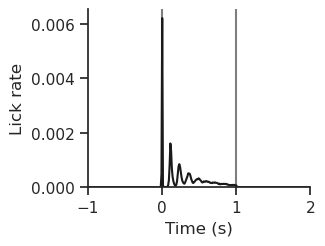

In [28]:
# All trials
licks = get_peri_event_licks(df, event=event)
bins, psth = compute_psth(licks, time_win=time_win, bin_size=bin_size)
figsize = fig_size(n_cols=2)
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # First lick
plt.axvline(1, color='tab:gray', linestyle='-')  # ITI
plot_lick_rate(bins, psth)
plt.ylim(0, None)

In [17]:
def mean_lick_rate(df, time_win=[-1, 2], bin_size=0.01, event='RespWinEnd'):
    """
    Get mean lick PSTH per session.
    :param df: DataFrame with behavior data
    :param time_win: time window around event
    :param bin_size: size of bins for PSTH (in seconds)
    :param event: event to align to ('RespWinEnd' for first lick)
    """

    session_ids = df['Session'].unique()
    session_psths = []
    for session in session_ids:
        df_session = df[df['Session'] == session].reset_index(drop=True)
        licks = get_peri_event_licks(df_session, event=event)
        bins, psth = compute_psth(licks, time_win=time_win, bin_size=bin_size)
        session_mean = np.mean(psth, axis=0)
        session_psths.append(session_mean)

    # Convert to 2D array: sessions × bins
    session_psths = np.array(session_psths)

    return bins, session_psths

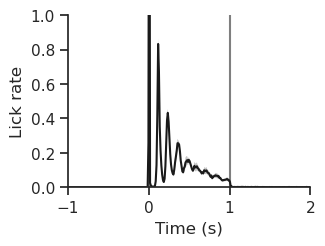

In [18]:
# All trials
figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[1]/2)
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # First lick
plt.axvline(1, color='tab:gray', linestyle='-')  # ITI
bins, session_psths = mean_lick_rate(df)
plot_lick_rate(bins, session_psths)

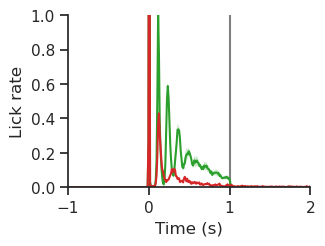

In [19]:
# Split by outcome
figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[1]/2)
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # First lick
plt.axvline(1, color='tab:gray', linestyle='-')  # ITI
bins, session_psth_correct = mean_lick_rate(df[df.Hit==1])
plot_lick_rate(bins, session_psth_correct, color='tab:green')
bins, session_psth_error = mean_lick_rate(df[df.Hit==0])
plot_lick_rate(bins, session_psth_error, color='tab:red')

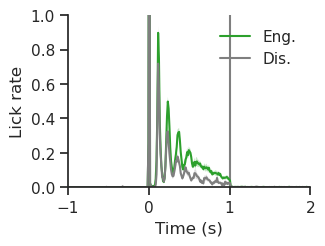

In [20]:
# Split by engagement
figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[1]/2)
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # First lick
plt.axvline(1, color='tab:gray', linestyle='-')  # ITI
bins, session_psth_correct = mean_lick_rate(df[df.State==1])
plot_lick_rate(bins, session_psth_correct, color='tab:green', label='Eng.')
bins, session_psth_error = mean_lick_rate(df[df.State==0])
plot_lick_rate(bins, session_psth_error, color='tab:gray', label='Dis.')
plt.legend(frameon=False)

In [ ]:
# error_sessions = {s: preprocess_subject(s) for s in subjects}
#
# ephys_ids = {}
# for subject in subjects:
#     ephys_ids[subject] = get_ephys_sessions(subject)
#     ephys_ids[subject] = [id for id in ephys_ids[subject] if id not in error_sessions[subject]]
#
# behavior = {}
# for subject in subjects:
#     folder_parent = Path.home() / 'data' / subject
#     behavior[subject] = []
#     for i in ephys_ids[subject]:
#         path_behavior = get_behavior_id(i)
#         filename = path_behavior.name
#         folder_child = folder_parent / i
#         df = pd.read_csv(folder_child / filename)
#         behavior[subject].append(df)
#
# folder_parent = Path.home() / 'data'

Bad sessions:

- 007
    - '007_2024-07-06_11-16-25'
    - '007_2024-07-07_13-20-29'
    - '007_2024-07-12_13-29-26'. # ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1. Extreme right bias

In [6]:
compute = False  # Flag to recompute decoders or load saved results

First, we will address 2 basic questions with the simplest decoder (within time bin), using only correct (so decoding stimulus or choice is equivalent) engaged trials :
- Does decoding accuracy changes per cluster group (single units vs MUA)?
- Does decoding accuracy changes thorugh cortical depth?

## Decoding accuracy split by depth

### Decode choice

#### Engaged

In [ ]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept
within_decoder took 1.63 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder took 1.96 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder took 1.43 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder took 1.66 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder took 1.58 seconds to run
mean_decoder took 10.07 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58

#### Disengaged

Train and test in disengaged (probably wrong)

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


within_decoder took 1.73 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder took 1.78 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder took 1.53 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder took 1.55 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder took 1.39 seconds to run
mean_decoder took 9.67 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 731 units by depth
450 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


within_decoder took 1.84 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 673 units by depth
351 / 1024 units kept
within_decoder took 1.83 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 428 units by depth
215 / 643 units kept
within_decoder took 1.57 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 413 units by depth
318 / 731 units kept
within_decoder took 1.63 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 459 units by depth
316 / 775 units kept
within_decoder took 1.50 seconds to run
mean_decoder took 9.70 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 805 units by depth
376 / 1181 units kept


...

within_decoder took 1.13 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 361 units by depth
124 / 485 units kept
within_decoder took 1.37 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 92 units by depth
11 / 103 units kept
within_decoder took 1.31 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 164 units by depth
71 / 235 units kept
within_decoder took 1.66 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 1.75 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 117 units by depth
66 / 183 units kept
within_decoder took 1.57 seconds to run
mean_decoder took 14.74 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 969, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.26 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 273 units by depth
212 / 485 units kept
within_decoder took 1.40 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 77 units by depth
26 / 103 units kept
within_decoder took 1.32 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 129 units by depth
106 / 235 units kept
within_decoder took 1.80 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 1.84 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 115 units by depth
68 / 183 units kept
within_decoder took 1.57 seconds to run
mean_decoder took 15.17 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 969, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.27 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 336 units by depth
149 / 485 units kept
within_decoder took 1.40 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 37 units by depth
66 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 177 units by depth
58 / 235 units kept
within_decoder took 1.67 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 192 units by depth
154 / 346 units kept
within_decoder took 2.08 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 134 units by depth
49 / 183 units kept
within_decoder took 1.57 seconds to run
mean_decoder took 15.53 seconds to run


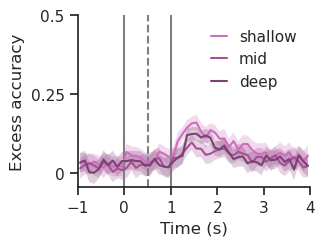

In [6]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

Train in engaged and test in disengaged (probably correct)

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept
within_decoder_generalize took 2.64 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder_generalize took 2.67 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder_generalize took 1.60 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder_generalize took 1.76 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder_generalize took 1.65 seconds to run
mean_decoder took 12.06 seconds to run
Development mode: r

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.35 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 361 units by depth
124 / 485 units kept
within_decoder_generalize took 1.95 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 92 units by depth
11 / 103 units kept
within_decoder_generalize took 1.35 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 164 units by depth
71 / 235 units kept
within_decoder_generalize took 1.72 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder_generalize took 1.89 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 117 units by depth
66 / 183 units kept
within_decoder_generalize took 1.82 seconds to run
mean_decoder took 16.77 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.58 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 273 units by depth
212 / 485 units kept
within_decoder_generalize took 2.44 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 77 units by depth
26 / 103 units kept
within_decoder_generalize took 1.45 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 129 units by depth
106 / 235 units kept
within_decoder_generalize took 2.00 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder_generalize took 2.03 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 115 units by depth
68 / 183 units kept
within_decoder_generalize took 1.80 seconds to run
mean_decoder took 18.51 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '00

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.78 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 336 units by depth
149 / 485 units kept
within_decoder_generalize took 2.33 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 37 units by depth
66 / 103 units kept
within_decoder_generalize took 1.70 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 177 units by depth
58 / 235 units kept
within_decoder_generalize took 1.70 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 192 units by depth
154 / 346 units kept
within_decoder_generalize took 2.25 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 134 units by depth
49 / 183 units kept
within_decoder_generalize took 1.77 seconds to run
mean_decoder took 19.22 seconds to run


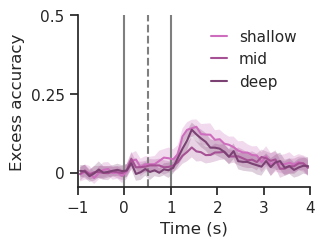

In [6]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='stim', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

### Decode previous choice

#### Engaged

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept
within_decoder took 1.64 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder took 2.07 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder took 1.43 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder took 1.70 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder took 1.61 seconds to run
mean_decoder took 11.10 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.34 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 361 units by depth
124 / 485 units kept
within_decoder took 2.01 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 92 units by depth
11 / 103 units kept
within_decoder took 1.25 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 164 units by depth
71 / 235 units kept
within_decoder took 1.61 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 2.00 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 117 units by depth
66 / 183 units kept
within_decoder took 1.86 seconds to run
mean_decoder took 17.03 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.57 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 273 units by depth
212 / 485 units kept
within_decoder took 2.58 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 77 units by depth
26 / 103 units kept
within_decoder took 1.33 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 129 units by depth
106 / 235 units kept
within_decoder took 1.96 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 2.01 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 115 units by depth
68 / 183 units kept
within_decoder took 1.85 seconds to run
mean_decoder took 18.46 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.83 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 336 units by depth
149 / 485 units kept
within_decoder took 2.54 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 37 units by depth
66 / 103 units kept
within_decoder took 1.59 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 177 units by depth
58 / 235 units kept
within_decoder took 1.66 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 192 units by depth
154 / 346 units kept
within_decoder took 2.28 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 134 units by depth
49 / 183 units kept
within_decoder took 1.83 seconds to run
mean_decoder took 19.53 seconds to run


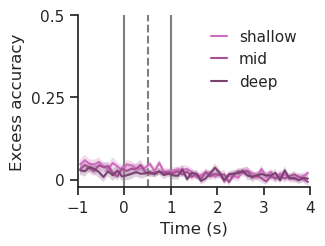

In [5]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=1, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
# plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
# plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

#### Disengaged

Train and test in disengaged (probably wrong)

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 992, in mean_decoder
    within_decoder(all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 255, in within_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 

An error occurred in session 000_2024-07-08_14-58-57: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1.0
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder took 2.31 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder took 2.23 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder took 1.87 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder took 1.44 seconds to run
mean_decoder took 10.13 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Remove

/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 992, in mean_decoder
    within_decoder(all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 255, in within_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 

An error occurred in session 000_2024-07-08_14-58-57: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1.0
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 673 units by depth
351 / 1024 units kept
within_decoder took 1.85 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 428 units by depth
215 / 643 units kept
within_decoder took 1.56 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 413 units by depth
318 / 731 units kept
within_decoder took 1.61 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 459 units by depth
316 / 775 units kept
within_decoder took 1.50 seconds to run
mean_decoder took 8.41 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed

...

within_decoder took 1.13 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 361 units by depth
124 / 485 units kept
within_decoder took 1.34 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 92 units by depth
11 / 103 units kept
within_decoder took 1.32 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 164 units by depth
71 / 235 units kept
within_decoder took 1.69 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 1.84 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 117 units by depth
66 / 183 units kept
within_decoder took 1.57 seconds to run
mean_decoder took 14.94 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.24 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 273 units by depth
212 / 485 units kept
within_decoder took 1.36 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 77 units by depth
26 / 103 units kept
within_decoder took 1.32 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 129 units by depth
106 / 235 units kept
within_decoder took 1.83 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder took 1.98 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 115 units by depth
68 / 183 units kept
within_decoder took 1.56 seconds to run
mean_decoder took 15.43 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.26 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 336 units by depth
149 / 485 units kept
within_decoder took 1.36 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 37 units by depth
66 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 177 units by depth
58 / 235 units kept
within_decoder took 1.72 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 192 units by depth
154 / 346 units kept
within_decoder took 2.30 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 134 units by depth
49 / 183 units kept
within_decoder took 1.57 seconds to run
mean_decoder took 15.89 seconds to run


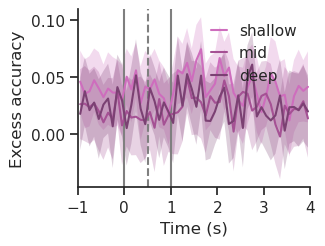

In [10]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='prev_choice', kind='within', hit_only=True, engagement=0, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
# plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
# plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

Train in engaged and test in disengaged (probably correct)

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 826 units by depth
355 / 1181 units kept
within_decoder_generalize took 1.75 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 655 units by depth
369 / 1024 units kept
within_decoder_generalize took 2.47 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 435 units by depth
208 / 643 units kept
within_decoder_generalize took 2.66 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 469 units by depth
262 / 731 units kept
within_decoder_generalize took 2.28 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 602 units by depth
173 / 775 units kept
within_decoder_generalize took 1.95 seconds to run
mean_decoder took 13.50 seconds to run
Development mode: r

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.36 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 361 units by depth
124 / 485 units kept
within_decoder_generalize took 2.16 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 92 units by depth
11 / 103 units kept
within_decoder_generalize took 1.38 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 164 units by depth
71 / 235 units kept
within_decoder_generalize took 1.76 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder_generalize took 2.17 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 117 units by depth
66 / 183 units kept
within_decoder_generalize took 1.92 seconds to run
mean_decoder took 17.57 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.59 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 273 units by depth
212 / 485 units kept
within_decoder_generalize took 2.61 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 77 units by depth
26 / 103 units kept
within_decoder_generalize took 1.48 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 129 units by depth
106 / 235 units kept
within_decoder_generalize took 2.11 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 250 units by depth
96 / 346 units kept
within_decoder_generalize took 2.17 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 115 units by depth
68 / 183 units kept
within_decoder_generalize took 1.91 seconds to run
mean_decoder took 18.96 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '00

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 954, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder_generalize took 1.88 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 336 units by depth
149 / 485 units kept
within_decoder_generalize took 2.47 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 37 units by depth
66 / 103 units kept
within_decoder_generalize took 1.75 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 177 units by depth
58 / 235 units kept
within_decoder_generalize took 1.79 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 192 units by depth
154 / 346 units kept
within_decoder_generalize took 2.45 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 134 units by depth
49 / 183 units kept
within_decoder_generalize took 1.88 seconds to run
mean_decoder took 19.88 seconds to run


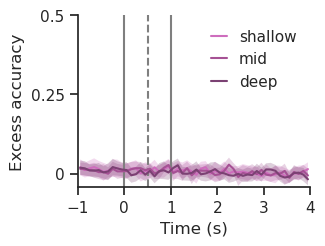

In [6]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

# Bin depth into 3 equal bins
depth_bins = [(0, 4/3), (4/3, 8/3), (8/3, 4)]
depth_labels = ['shallow', 'mid', 'deep']

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='prev_choice', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[0], save=False)
    results_1 = mean_decoder(subj, what='prev_choice', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[1], save=False)
    results_2 = mean_decoder(subj, what='prev_choice', kind='within_generalize', hit_only=True, split_by='State', engagement=None, group=None, depth=depth_bins[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20b
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=depth_labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=depth_labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=depth_labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
# plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
# plt.ylim(None, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

The stimulus code (0-0.5 s) decreases with depth. The delay code (0.5-1 s) remarkably decreases almost to chance below M2 (depth > 1.5 mm, i.e. mid and deep bins). The response code (1-2 s) decreases only in the mid bin, maybe due to penetrating the corpues callosum in some sessions, yielding fewer units.

## Decoding accuracy split by cluster group

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
within_decoder took 2.75 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
within_decoder took 3.21 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
within_decoder took 1.92 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
within_decoder took 2.39 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
within_decoder took 2.33 seconds to run
mean_decoder took 15.10 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing sessio

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.88 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
within_decoder took 2.91 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
within_decoder took 1.60 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
within_decoder took 2.05 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
within_decoder took 2.53 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
within_decoder took 2.24 seconds to run
mean_decoder took 21.97 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
Removed 209 

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.37 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 324 units by group
161 / 485 units kept
within_decoder took 2.32 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 100 units by group
3 / 103 units kept
within_decoder took 1.10 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 215 units by group
20 / 235 units kept
within_decoder took 1.34 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 346 units by group
0 / 346 units kept
An error occurred in session 009_2024-05-23_17-40-35: Found array with 0 feature(s) (shape=(192, 0)) while a minimum of 1 is required by StandardScaler.
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 180 units by group
3 / 183 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 931, in mean_decoder
    within_decoder(all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 250, in within_decoder
    X_train = scaler.fit_transform(X_train)  # Fit and transform on the training set
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/utils/_set_output.py", line 319, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 918, in fit_transform
    return self.fit(X, **fit_params).transform(X)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/preprocessing/_data.py", line 894, in fit
    return self.partial_fit(X, y, sample_weight)
  File "/ho

within_decoder took 1.19 seconds to run
mean_decoder took 13.72 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
Removed 56 units by group
209 / 265 units kept
within_decoder took 2.27 seconds to run
Processing session 2/9: 009_2024-05-09_20-59-38...
Removed 55 units by group
256 / 311 units kept
within_decoder took 2.18 seconds to run
Processing session 3/9: 009_2024-05-10_17-38-35...
Removed 37 units by group
198 / 235 units kept
An error occurred in session 009_2024-05-10_17-38-35: 
Processing session 4/9: 009_2024-05-11_13-06-51...
Removed 32 units by group
157 / 189 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.87 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 161 units by group
324 / 485 units kept
within_decoder took 2.60 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 3 units by group
100 / 103 units kept
within_decoder took 1.60 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 20 units by group
215 / 235 units kept
within_decoder took 2.03 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 0 units by group
346 / 346 units kept
within_decoder took 2.50 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 3 units by group
180 / 183 units kept
within_decoder took 2.19 seconds to run
mean_decoder took 20.73 seconds to run


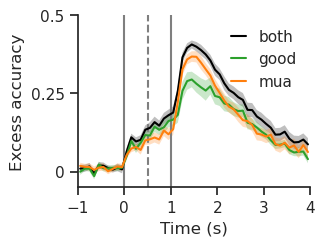

In [16]:
# Compare decoding accuracy across depth bins
# Inserted first bank of channels of Neuropixels 1.0 (3.84 mm of first bank + 0.175 of the probe tip = 4.015 mm)

group = [None, 'good', 'mua']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=group[0], depth=None, save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=group[1], depth=None, save=False)
    results_2 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=group[2], depth=None, save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
colors = ['black', 'tab:green', 'tab:orange']
labels = ['both', 'good', 'mua']

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(-0.05, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

Decoding accuracy dynamics largely remaines regardless of the clusters grouping factor, but peak decreases as more clusters are excluded. For the rest of the analyses all clusters (good and mua) from all depths will be used, unless otherwise stated.

## Decoding accuracy split by Fano factor

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
Removed 483 units by Fano factor
698 / 1181 units kept
within_decoder took 1.90 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
Removed 430 units by Fano factor
594 / 1024 units kept
within_decoder took 2.25 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
Removed 264 units by Fano factor
379 / 643 units kept
within_decoder took 1.58 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
Removed 412 units by Fano factor
319 / 731 units kept
within_decoder took 1.74 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
Removed 286 units by Fano factor
489 / 775 units kept
within_decoder took 1.79 seconds to run
mean_decoder took 11.88 seconds to run
Development mode: remote (minibaps, alexis, 

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.87 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 197 units by Fano factor
288 / 485 units kept
within_decoder took 2.64 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 31 units by Fano factor
72 / 103 units kept
within_decoder took 1.57 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 93 units by Fano factor
142 / 235 units kept
within_decoder took 1.93 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 277 units by Fano factor
69 / 346 units kept
within_decoder took 1.63 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 150 units by Fano factor
33 / 183 units kept
within_decoder took 1.48 seconds to run
mean_decoder took 19.56 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.90 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 59 units by Fano factor
426 / 485 units kept
within_decoder took 2.85 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 12 units by Fano factor
91 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 38 units by Fano factor
197 / 235 units kept
within_decoder took 1.99 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 202 units by Fano factor
144 / 346 units kept
within_decoder took 1.81 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 70 units by Fano factor
113 / 183 units kept
within_decoder took 1.95 seconds to run
mean_decoder took 20.52 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.88 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
Removed 18 units by Fano factor
467 / 485 units kept
within_decoder took 2.90 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
Removed 6 units by Fano factor
97 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
Removed 10 units by Fano factor
225 / 235 units kept
within_decoder took 2.03 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
Removed 114 units by Fano factor
232 / 346 units kept
within_decoder took 2.07 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
Removed 24 units by Fano factor
159 / 183 units kept
within_decoder took 2.15 seconds to run
mean_decoder took 20.92 seconds to run


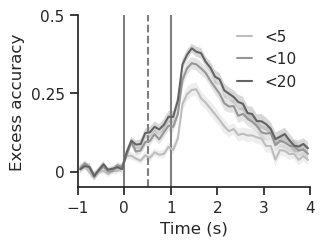

In [17]:
# Compare decoding accuracy between Fano factor cutoffs

max_fano = [5, 10, 20]
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}
mean_results_2 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=None, max_fano=max_fano[0], save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=None, max_fano=max_fano[1], save=False)
    results_2 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=None, max_fano=max_fano[2], save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']
        mean_results_2[k].extend(results_2.get(k, []))
        mean_results_2['bins'] = results_2['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_2, acc_mean_2, acc_band_2 = plot_mean_within_decoder(mean_results_2, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
cmap = plt.cm.tab20c
colors = [cmap(i) for i in range(16, 19)]  # Pinks
colors = colors[::-1]  # Reverse
labels = ['<' + str(max_fano[i]) for i in range(len(max_fano))]

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_2, acc_mean_2, color=colors[2], label=labels[2])
plt.fill_between(bin_centers_2, acc_band_2[0], acc_band_2[1], color=colors[2], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(-0.05, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

## Decoding accuracy split by engagement

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
within_decoder took 2.84 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
within_decoder took 2.61 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
within_decoder took 1.95 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
within_decoder took 1.99 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
within_decoder took 1.79 seconds to run
mean_decoder took 13.53 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing sessio

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 931, in mean_decoder
    within_decoder(all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 255, in within_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1


within_decoder took 3.05 seconds to run
Processing session 2/15: 007_2024-06-23_12-46-55...
701 / 701 units kept
within_decoder took 3.22 seconds to run
Processing session 3/15: 007_2024-06-24_17-47-22...
686 / 686 units kept
within_decoder took 4.27 seconds to run
Processing session 4/15: 007_2024-06-25_15-54-23...
685 / 685 units kept
within_decoder took 3.32 seconds to run
Processing session 5/15: 007_2024-06-26_15-19-30...
721 / 721 units kept
within_decoder took 3.35 seconds to run
Processing session 6/15: 007_2024-06-27_15-06-28...
347 / 347 units kept
within_decoder took 2.14 seconds to run
Processing session 7/15: 007_2024-06-28_14-18-51...
891 / 891 units kept
within_decoder took 3.70 seconds to run
Processing session 8/15: 007_2024-06-29_16-24-52...
685 / 685 units kept
within_decoder took 4.14 seconds to run
Processing session 9/15: 007_2024-07-06_11-16-25...
619 / 619 units kept
within_decoder took 1.74 seconds to run
Processing session 10/15: 007_2024-07-07_13-20-29...
364

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.34 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
within_decoder took 1.67 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
within_decoder took 1.83 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
within_decoder took 1.95 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
within_decoder took 2.68 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
within_decoder took 1.79 seconds to run
mean_decoder took 18.20 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 un

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.88 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
within_decoder took 3.01 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
within_decoder took 2.04 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
within_decoder took 2.52 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
within_decoder took 2.25 seconds to run
mean_decoder took 21.67 seconds to run


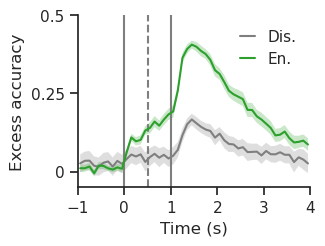

In [18]:
# Compare decoding accuracy between correct engaged and correct disengaged trials

mean_results_0 = {k: [] for k in keys}
mean_results_1 = {k: [] for k in keys}

for subj in subjects:

    results_0 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=0, group=None, depth=None, save=False)
    results_1 = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, group=None, depth=None, save=False)

    for k in keys:
        mean_results_0[k].extend(results_0.get(k, []))
        mean_results_0['bins'] = results_0['bins']
        mean_results_1[k].extend(results_1.get(k, []))
        mean_results_1['bins'] = results_1['bins']

# Plot mean within decoder results across mice
bin_centers_0, acc_mean_0, acc_band_0 = plot_mean_within_decoder(mean_results_0, errorbar='sem', z_null=False, excess=True); plt.close()
bin_centers_1, acc_mean_1, acc_band_1 = plot_mean_within_decoder(mean_results_1, errorbar='sem', z_null=False, excess=True); plt.close()

# Plot
colors = ['tab:gray', 'tab:green']
labels = ['Dis.', 'En.']

plt.figure(constrained_layout=True, figsize=fig_size(n_cols=2))
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue

# Plot the mean decoding accuracy across all sessions
plt.plot(bin_centers_0, acc_mean_0, color=colors[0], label=labels[0])
plt.fill_between(bin_centers_0, acc_band_0[0], acc_band_0[1], color=colors[0], edgecolor='none', alpha=0.25)
plt.plot(bin_centers_1, acc_mean_1, color=colors[1], label=labels[1])
plt.fill_between(bin_centers_1, acc_band_1[0], acc_band_1[1], color=colors[1], edgecolor='none', alpha=0.25)

x_start = int(np.floor(bin_centers_0[0]))
x_end = int(np.ceil(bin_centers_0[-1]))
xticks = np.arange(x_start, x_end + 1, 1)
plt.xlim(bin_centers_0[0], bin_centers_0[-1])
plt.xticks(xticks)
plt.xlabel('Time (s)')
plt.yticks((0, 0.25, 0.5), ('0', '0.25', '0.5'))
plt.ylim(-0.05, 0.5)
plt.ylabel('Excess accuracy')
plt.legend(loc='upper right', frameon=False, handlelength=1)
sns.despine()

# Within temporal decoder

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
within_decoder took 2.87 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
within_decoder took 3.08 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
within_decoder took 1.84 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
within_decoder took 2.22 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
within_decoder took 2.21 seconds to run
mean_decoder took 16.16 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 880, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


within_decoder took 1.92 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
within_decoder took 2.96 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
within_decoder took 1.61 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
within_decoder took 2.03 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
within_decoder took 2.51 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
within_decoder took 2.25 seconds to run
mean_decoder took 22.51 seconds to run


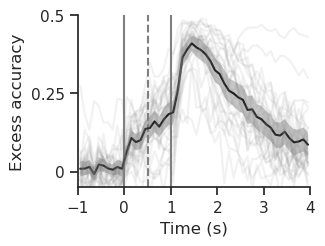

In [62]:
figsize = fig_size(n_cols=2)

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean within decoder across sessions
        results = mean_decoder(subj, what='stim', kind='within', hit_only=True, engagement=1, save=True)
    else:  # Load mean within decoder results across sessions
        filename = 'stim_within_decoder_hit_only_engaged (stim aligned).pkl'  # Hit only, engaged
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean within decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_within_decoder(results, z_null=False)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_within_decoder(mean_results, z_null=False, excess=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

# Cross temporal decoder

## Aligned to stimulus onset

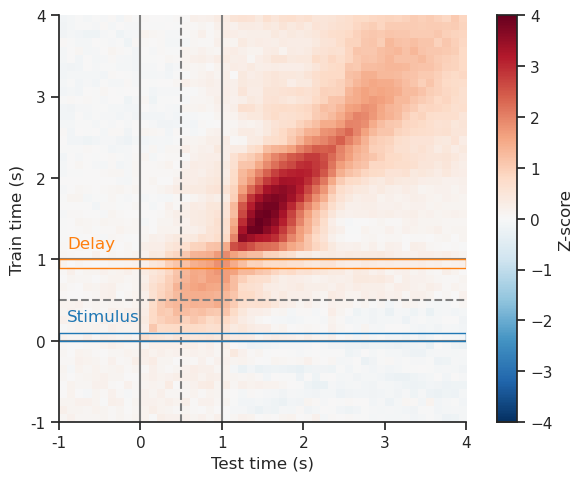

In [103]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean cross decoder across sessions
        results = mean_decoder(what='stim', align='stim', kind='cross', hit_only=True, engagement=1, save=True)
    else:  # Load mean within decoder results across sessions
        filename = 'stim_cross_hit_only_engaged_(stim_aligned).pkl'
        # filename = 'stim_cross_hit_only_engaged_(resp aligned).pkl'
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, align='stim', z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

## Aligned to first lick

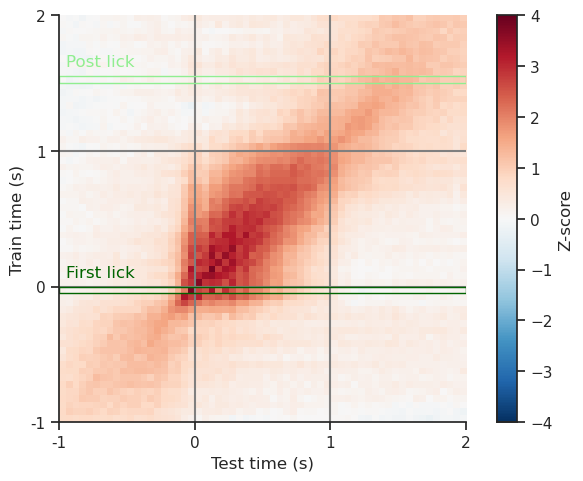

In [21]:
figsize = fig_size(n_cols=1)

keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights']
mean_results = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean cross decoder across sessions
        results = mean_decoder(kind='cross', save=True)
        results = mean_decoder(what='stim', align='resp', kind='cross', hit_only=True, engagement=1, save=True)
    else:  # Load mean within decoder results across sessions
        filename = 'stim_cross_hit_only_engaged_(resp_aligned).pkl'
        path = Path(folder_parent / subj / filename)
        with open(path, 'rb') as f:
            results = pickle.load(f)

    for k in keys:
        mean_results[k].extend(results.get(k, []))
        mean_results['bins'] = results['bins']

    # # Plot mean cross decoder results across sessions for each subject
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_cross_decoder(results, z_null=True)
    # n_sessions = len(results['acc'])
    # n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plot_mean_cross_decoder(mean_results, align='resp', z_null=True)
n_sessions = len(mean_results['acc'])
n_trials = np.sum([mean_results['acc'][i].shape[0] for i in range(len(mean_results['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

# Epoch cross temporal decoder
Aligned to stimulus onset

(-0.05, 0.25)

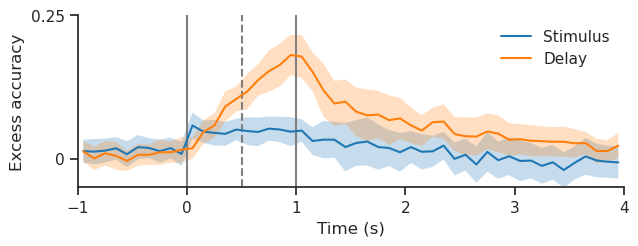

In [22]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[1]/2)

# keys = ['acc', 'acc_null', 'pred', 'pred_err']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights', 'weights_null', 'dv', 'dv_null', 'df']

mean_results_stim = {k: [] for k in keys}
mean_results_delay = {k: [] for k in keys}
# mean_results_resp = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_stim = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='stim', hit_only=True, engagement=1, n_shuffles=100, save=True)
        results_delay = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='delay', hit_only=True, engagement=1, n_shuffles=100, save=True)
        # results_resp = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='resp', hit_only=True, engagement=1, n_shuffles=100, save=True)
    else:  # Load mean epoch cross decoder results across sessions
        filename_stim = 'stim_epoch_decoder_stim_hit_only_engaged_(stim_aligned).pkl'
        filename_delay = 'stim_epoch_decoder_delay_hit_only_engaged_(stim_aligned).pkl'
        # filename_resp = 'stim_epoch_decoder_resp_hit_only_engaged_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_stim), 'rb') as f:
            results_stim = pickle.load(f)
        with open(Path(folder_parent / subj / filename_delay), 'rb') as f:
            results_delay = pickle.load(f)
        # with open(Path(folder_parent / subj / filename_resp), 'rb') as f:
        #     results_resp = pickle.load(f)

    for k in keys:
        mean_results_stim[k].extend(results_stim.get(k, []))
        mean_results_stim['bins'] = results_stim['bins']
        mean_results_delay[k].extend(results_delay.get(k, []))
        mean_results_delay['bins'] = results_delay['bins']
        # mean_results_resp[k].extend(results_resp.get(k, []))
        # mean_results_resp['bins'] = results_resp['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
    # # plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue
plot_mean_epoch_cross_decoder(mean_results_stim, epoch='stim', excess=True, errorbar='ci', z_null=True)
plot_mean_epoch_cross_decoder(mean_results_delay, epoch='delay', excess=True, errorbar='ci', z_null=True)
# plot_mean_epoch_cross_decoder(mean_results_resp, epoch='resp', excess=True, errorbar='ci', z_null=True)
n_sessions = len(mean_results_stim['acc'])
n_trials = np.sum([mean_results_stim['acc'][i].shape[0] for i in range(len(mean_results_stim['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
# plt.gca().get_legend().remove()
plt.ylim(None, 0.25)

## Plot weights distributions for the 3 codes

### From the epoch decoder

Text(0.5, 1.0, 'Response\n(18% selective units)')

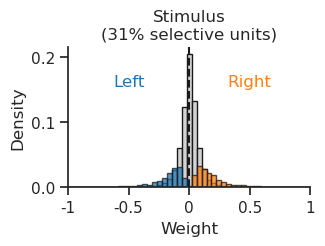

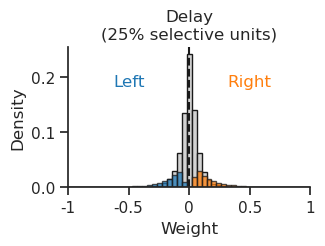

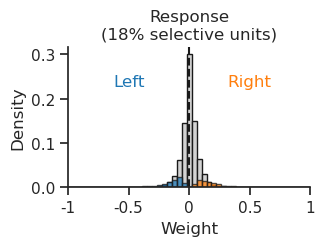

In [9]:
# Stimulus
weights_stim = []
selective_mask_stim = []
n_selective_stim = []
for w, w_null in zip(mean_results_stim['weights'], mean_results_stim['weights_null']):
    weights_stim.append(w.mean(axis=0))
    selective_mask = get_selective_units(w, w_null)
    selective_mask_stim.append(selective_mask)
    n_selective_stim.append(sum(selective_mask))
# weights_stim = np.concatenate(weights_stim)
# selective_mask_stim = np.concatenate(selective_mask_stim)
# plot_weights_dist(weights_stim, selective_mask_stim)
plot_weights_dist(np.concatenate(weights_stim), np.concatenate(selective_mask_stim))
title = plt.gca().get_title()
plt.title(f'Stimulus\n({title})')

# Delay
weights_delay = []
selective_mask_delay = []
n_selective_delay = []
for w, w_null in zip(mean_results_delay['weights'], mean_results_delay['weights_null']):
    weights_delay.append(w.mean(axis=0))
    selective_mask = get_selective_units(w, w_null)
    selective_mask_delay.append(selective_mask)
    n_selective_delay.append(sum(selective_mask))
# weights_delay = np.concatenate(weights_delay)
# selective_mask_delay = np.concatenate(selective_mask_delay)
# plot_weights_dist(weights_delay, selective_mask_delay)
plot_weights_dist(np.concatenate(weights_delay), np.concatenate(selective_mask_delay))
title = plt.gca().get_title()
plt.title(f'Delay\n({title})')

# Response
weights_resp = []
selective_mask_resp = []
n_selective_resp = []
for w, w_null in zip(mean_results_resp['weights'], mean_results_resp['weights_null']):
    weights_resp.append(w.mean(axis=0))
    selective_mask = get_selective_units(w, w_null)
    selective_mask_resp.append(selective_mask)
    n_selective_resp.append(sum(selective_mask))
# weights_resp = np.concatenate(weights_resp)
# selective_mask_resp = np.concatenate(selective_mask_resp)
# plot_weights_dist(weights_resp, selective_mask_resp)
plot_weights_dist(np.concatenate(weights_resp), np.concatenate(selective_mask_resp))
title = plt.gca().get_title()
plt.title(f'Response\n({title})')

### From the Poisson GLM

In [7]:
compute = True

In [9]:
keys = ['params', 'pvalues', 'selective_mask', 'cluster_info']

mean_selectivity_stim = {k: [] for k in keys}
mean_selectivity_delay = {k: [] for k in keys}
mean_selectivity_resp = {k: [] for k in keys}

for subj in subjects:

    if compute:
        selectivity_stim = mean_selectivity(subj, what='stim', align='stim', epoch='stim', group=None, depth=None, min_fr=None, max_fano=None, alpha=0.05, n_shuffles=0, save=True)
        selectivity_delay = mean_selectivity(subj, what='stim', align='stim', epoch='delay', group=None, depth=None, min_fr=None, max_fano=None, alpha=0.05, n_shuffles=0, save=True)
        selectivity_resp = mean_selectivity(subj, what='stim', align='stim', epoch='resp', group=None, depth=None, min_fr=None, max_fano=None, alpha=0.05, n_shuffles=0, save=True)
    else:
        filename_stim = 'stim_selectivity_stim_(stim_aligned).pkl'
        filename_delay = 'stim_selectivity_delay_(stim_aligned).pkl'
        filename_resp = 'stim_selectivity_resp_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_stim), 'rb') as f:
            selectivity_stim = pickle.load(f)
        with open(Path(folder_parent / subj / filename_delay), 'rb') as f:
            selectivity_delay = pickle.load(f)
        with open(Path(folder_parent / subj / filename_resp), 'rb') as f:
            selectivity_resp = pickle.load(f)

    for k in keys:
        mean_selectivity_stim[k].extend(selectivity_stim.get(k, []))
        mean_selectivity_delay[k].extend(selectivity_delay.get(k, []))
        mean_selectivity_resp[k].extend(selectivity_resp.get(k, []))

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
stim selectivity: 6.8% (80/1181 neurons)
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
stim selectivity: 8.6% (88/1024 neurons)
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
stim selectivity: 3.0% (19/643 neurons)
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
stim selectivity: 6.4% (47/731 neurons)
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
stim selectivity: 14.1% (109/775 neurons)
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 1187, in mean_selectivity
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


stim selectivity: 7.9% (15/189 neurons)
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
stim selectivity: 9.7% (47/485 neurons)
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
stim selectivity: 1.9% (2/103 neurons)
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
stim selectivity: 11.1% (26/235 neurons)
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
stim selectivity: 24.0% (83/346 neurons)
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
stim selectivity: 30.6% (56/183 neurons)
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 units kept
delay selectivity: 5.3% (14/

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 1187, in mean_selectivity
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


delay selectivity: 11.6% (22/189 neurons)
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
delay selectivity: 14.2% (69/485 neurons)
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
delay selectivity: 3.9% (4/103 neurons)
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
delay selectivity: 22.1% (52/235 neurons)
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
delay selectivity: 70.8% (245/346 neurons)
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
delay selectivity: 20.2% (37/183 neurons)
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 units kept
resp selectivity: 2

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 1187, in mean_selectivity
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


resp selectivity: 13.2% (25/189 neurons)
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
resp selectivity: 29.5% (143/485 neurons)
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
resp selectivity: 16.5% (17/103 neurons)
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
resp selectivity: 63.4% (149/235 neurons)
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
resp selectivity: 73.1% (253/346 neurons)
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
resp selectivity: 64.5% (118/183 neurons)


Text(0.5, 1.0, 'Response\n(25%)')

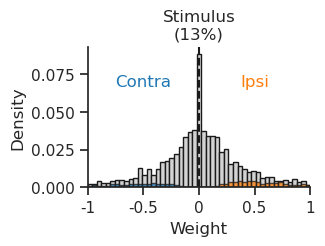

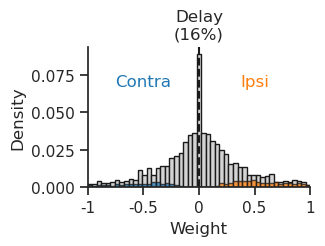

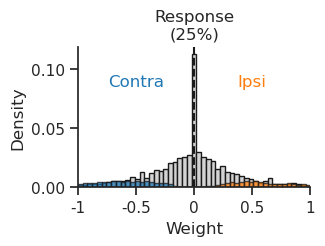

In [30]:
# Stimulus
cluster_info_stim = add_selectivity_cluster_info(mean_selectivity_stim)
weights_stim = cluster_info_stim.weights
selective_mask_stim = cluster_info_stim.selective_mask
plot_weights_dist(cluster_info_stim, ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Stimulus\n({title})')

# Delay
cluster_info_delay = add_selectivity_cluster_info(mean_selectivity_delay)
weights_delay = cluster_info_delay.weights
selective_mask_delay = cluster_info_delay.selective_mask
plot_weights_dist(cluster_info_delay, ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Delay\n({title})')

# Response
cluster_info_resp = add_selectivity_cluster_info(mean_selectivity_resp)
weights_resp = cluster_info_resp.weights
selective_mask_resp = cluster_info_resp.selective_mask
plot_weights_dist(cluster_info_resp, ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Response\n({title})')

In [43]:
def plot_weights_dist(cluster_info, ipsi_contra=False):

    weights = cluster_info['weights'].to_numpy()
    selective_mask = cluster_info['selective_mask'].to_numpy()
    rec_side = cluster_info['RECside'].to_numpy()  # 1 for right, 0 for left

    # Flip weights for ipsi/contra convention if requested
    if ipsi_contra:
        weights = lr2ic(weights, rec_side)
        labels = ('Contra', 'Ipsi')
    else:
        labels = ('Left', 'Right')

    non_selective = ~selective_mask
    negative_selective = selective_mask & (weights < 0)  # Left/Ipsi
    positive_selective = selective_mask & (weights > 0)  # Right/Contra

    # Plot single histogram, color by selectivity
    plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
    bins = np.linspace(-3, 3, 50)

    # Plot
    plt.hist(weights[non_selective], bins=bins, weights=np.ones(non_selective.sum())/len(weights),
             color='lightgray', edgecolor='k')
    plt.hist(weights[negative_selective], bins=bins, weights=np.ones(negative_selective.sum()) / len(weights),
             color='tab:blue', edgecolor='k', label=labels[0], alpha=0.75)
    plt.hist(weights[positive_selective], bins=bins, weights=np.ones(positive_selective.sum()) / len(weights),
             color='tab:orange', edgecolor='k', label=labels[1], alpha=0.75)

    plt.axvline(0, color='k', linestyle='--')
    plt.xlim(-3, 3)
    xticks = np.arange(-2, 2.01, 0.5)
    xticklabels = [f'{x:g}' for x in xticks]  # 'g' removes trailing zeros
    plt.xticks(xticks, xticklabels)
    plt.title(f'{selective_mask.sum() / len(weights) * 100:.0f}%')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    # plt.legend(loc='upper center', ncol=2)
    ylim = plt.gca().get_ylim()[1] * 0.75
    plt.text(-0.5, ylim, labels[0], color='tab:blue', ha='center', va='center')
    plt.text(0.5, ylim, labels[1], color='tab:orange', ha='center', va='center')
    sns.despine()

Text(0.5, 1.0, 'Response\n(100%)')

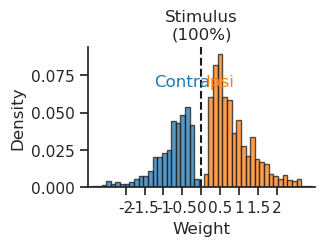

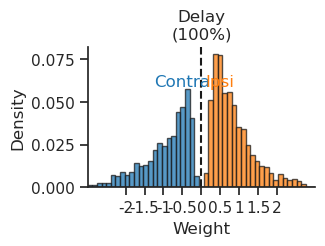

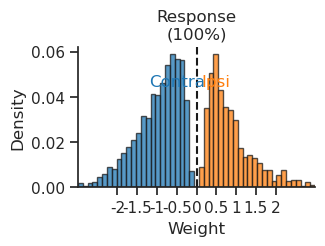

In [44]:
# Stimulus
cluster_info_stim = add_selectivity_cluster_info(mean_selectivity_stim)
plot_weights_dist(cluster_info_stim[cluster_info_stim.selective_mask], ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Stimulus\n({title})')

# Delay
cluster_info_delay = add_selectivity_cluster_info(mean_selectivity_delay)
plot_weights_dist(cluster_info_delay[cluster_info_delay.selective_mask], ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Delay\n({title})')

# Response
cluster_info_resp = add_selectivity_cluster_info(mean_selectivity_resp)
plot_weights_dist(cluster_info_resp[cluster_info_resp.selective_mask], ipsi_contra=True)
title = plt.gca().get_title()
plt.title(f'Response\n({title})')

## Licks
Aligned to first lick

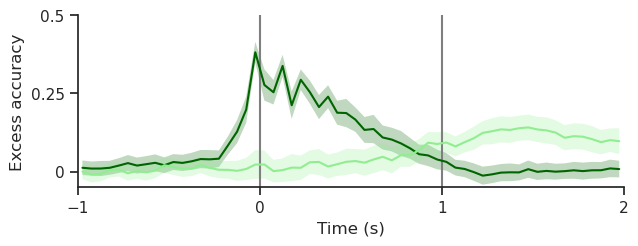

In [40]:
figsize = fig_size(n_cols=1)
figsize = (figsize[0], figsize[1]/2)

keys = ['acc', 'acc_null', 'pred', 'pred_err']

mean_results_first_lick = {k: [] for k in keys}
# mean_results_mid_lick = {k: [] for k in keys}
# mean_results_late_lick = {k: [] for k in keys}
mean_results_post_lick = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_first_lick = mean_decoder(subj, what='choice', align='resp', kind='epoch', epoch='first_lick', hit_only=True, engagement=1, n_shuffles=100, save=True)
        # results_mid_lick = mean_decoder(subj, what='choice', align='resp', kind='epoch', epoch='mid_lick', hit_only=True, engagement=1, n_shuffles=100, save=True)
        # results_late_lick = mean_decoder(subj, what='choice', align='resp', kind='epoch', epoch='late_lick', hit_only=True, engagement=1, n_shuffles=100, save=True)
        results_post_lick = mean_decoder(subj, what='choice', align='resp', kind='epoch', epoch='post_lick', hit_only=True, engagement=1, n_shuffles=100, save=True)

    else:  # Load mean epoch cross decoder results across sessions
        filename_first_lick = 'choice_epoch_decoder_first_lick_hit_only_engaged_(resp_aligned).pkl'
        # filename_mid_lick = 'choice_epoch_decoder_mid_lick_hit_only_engaged_(resp_aligned).pkl'
        # filename_late_lick = 'choice_epoch_decoder_late_lick_hit_only_engaged_(resp_aligned).pkl'
        filename_post_lick = 'choice_epoch_decoder_post_lick_hit_only_engaged_(resp_aligned).pkl'

        with open(Path(folder_parent / subj / filename_first_lick), 'rb') as f:
            results_first_lick = pickle.load(f)
        # with open(Path(folder_parent / subj / filename_mid_lick), 'rb') as f:
        #     results_mid_lick = pickle.load(f)
        # with open(Path(folder_parent / subj / filename_late_lick), 'rb') as f:
        #     results_late_lick = pickle.load(f)
        with open(Path(folder_parent / subj / filename_post_lick), 'rb') as f:
            results_post_lick = pickle.load(f)

    for k in keys:
        mean_results_first_lick[k].extend(results_first_lick.get(k, []))
        mean_results_first_lick['bins'] = results_first_lick['bins']
        # mean_results_mid_lick[k].extend(results_mid_lick.get(k, []))
        # mean_results_mid_lick['bins'] = results_mid_lick['bins']
        # mean_results_late_lick[k].extend(results_late_lick.get(k, []))
        # mean_results_late_lick['bins'] = results_late_lick['bins']
        mean_results_post_lick[k].extend(results_post_lick.get(k, []))
        mean_results_post_lick['bins'] = results_post_lick['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Go cue
plt.axvline(1, color='tab:gray', linestyle='-')  # ITI
plot_mean_epoch_cross_decoder(mean_results_first_lick, epoch='first_lick', excess=True, errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(mean_results_mid_lick, epoch='mid_lick', excess=True, errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(mean_results_late_lick, epoch='late_lick', excess=True, errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(mean_results_post_lick, epoch='post_lick', excess=True, errorbar='ci', z_null=False)
# plt.xlim(-1, None)
plt.ylim(None, 0.5)
n_sessions = len(mean_results_first_lick['acc'])
n_trials = np.sum([mean_results_first_lick['acc'][i].shape[0] for i in range(len(mean_results_first_lick['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

To do:
- Code overlap between stim and delay in epoch cross decoder (see Tiffany's paper Fig. 3g)
- Small bump in response code could be anticipatory licking (licks to the air). It could also be the motor getting stuck in the previous trial and not going back, therefore representing aberrant licks (licks that shouldn't be there). Check if there are aberrant licks (licks before the response window opens), remove them and see if the small bump disappears.

# Splits

In [7]:
def plot_mean_decoder_subjects_split(subjects, folder_parent, compute=False, what='stim', align='stim', kind='epoch_split', epoch='stim', split_by='Hit', excess=True, hit_only=None, engagement=None, n_shuffles=100, save=False):
    """
    Plot mean epoch cross decoder results across subjects split by outcome or engagement.
    :param subjects: list of subject IDs
    :param folder_parent: parent folder path
    :param compute: bool, whether to compute the decoder or load saved results
    :param what: str, what to decode ('stim' or 'choice')
    :param kind: str, kind of decoder ('epoch_split' or 'generalize')
    :param epoch: str, epoch to decode ('stim', 'delay', 'resp')
    :param split_by: str, how to split the data ('Hit' or 'Engaged')
    :param excess: bool, whether to plot excess accuracy
    :param engagement: int or None, engagement state to consider (1 for engaged, 0 for disengaged, None for all)
    :param n_shuffles: int, number of shuffles for null distribution
    :param save: bool, whether to save the computed results
    """

    figsize = fig_size(n_cols=2)

    keys = ['acc', 'acc_null', 'pred', 'pred_err']
    mean_results = {k: [] for k in keys}

    if split_by == 'Hit':
        filename = f'{what}_epoch_split_decoder_{epoch}_split_by_{split_by}_engaged_({align}_aligned).pkl'
        split = 'hit'
        if kind == 'generalize':
            filename = f'{what}_epoch_{kind}_decoder_{epoch}_{kind}_{split_by}_engaged_({align}_aligned).pkl'

    elif split_by == 'State':
        # filename = f'{what}_epoch_split_decoder_{epoch}_split_by_{split_by}_hit_only_({align} aligned).pkl'
        filename = f'{what}_epoch_generalize_decoder_{epoch}_generalize_{split_by}_hit_only_({align}_aligned).pkl'
        split = 'engagement'

    for subj in subjects:

        if compute:  # Run mean epoch cross decoder split across sessions
            results = mean_decoder(subj, what=what, align=align, kind=kind, epoch=epoch, split_by=split_by, hit_only=hit_only, engagement=engagement, n_shuffles=n_shuffles, save=save)
        else:  # Load mean within decoder results across sessions
            path = Path(folder_parent / subj / filename)
            with open(path, 'rb') as f:
                results = pickle.load(f)

        for k in keys:
            mean_results[k].extend(results.get(k, []))
            mean_results['bins'] = results['bins']

        # # Plot mean epoch cross decoder split results across sessions
        # plt.figure(constrained_layout=True, figsize=figsize)
        # plot_mean_epoch_cross_decoder_split(results, errorbar='ci', z_null=True)
        # n_sessions = len(results['acc'])
        # n_trials = np.sum([results['acc'][i][0].shape[0] for i in range(len(results['acc']))])
        # plt.title(f'Stimulus code\n'
        #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

    # Plot mean within decoder results across mice
    plt.figure(constrained_layout=True, figsize=figsize)
    plot_mean_epoch_cross_decoder_split(mean_results, what=what, epoch=epoch, split=split, excess=excess, errorbar='ci', z_null=False)
    n_sessions = len(mean_results['acc'])
    n_trials = np.sum([mean_results['acc'][i][0].shape[0] for i in range(len(mean_results['acc']))])
    # plt.title(f'Decoding accuracy ({epoch} epoch)\n'
    #           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')

## By Outcome

### Train in all trials and test split by outcome
Epoch cross temporal decoder split

#### Stimulus code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 0.89 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 1.02 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.78 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 0.90 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.89 seconds to run
mean_decoder took 7.12 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.82 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 1.02 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.79 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 0.86 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 0.87 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.87 seconds to run
mean_decoder took 11.40 seconds to run


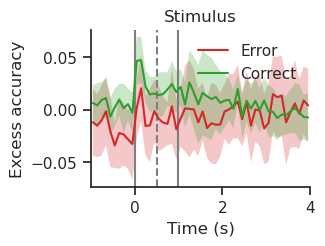

In [20]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='stim', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Stimulus')
plt.legend(loc='upper right')

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

In errors the stimulus is well represented, but the mouse prepare (delay) and execute (response) the wrong choice.

#### Delay code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 0.89 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 1.02 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.78 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 0.91 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.88 seconds to run
mean_decoder took 6.86 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.82 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 0.98 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.78 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 0.84 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 0.87 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.92 seconds to run
mean_decoder took 11.39 seconds to run


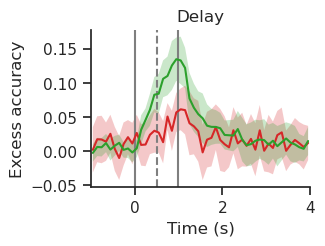

In [19]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='delay', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Delay')
plt.gca().get_legend().remove()

#### Response code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 0.90 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 1.01 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.85 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 0.91 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.89 seconds to run
mean_decoder took 7.34 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.83 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 0.97 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.79 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 0.84 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 0.89 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.87 seconds to run
mean_decoder took 11.34 seconds to run


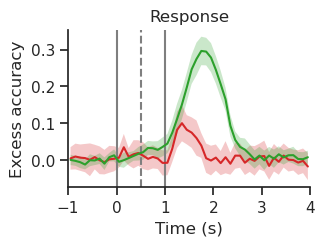

In [8]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='resp', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Response')
plt.gca().get_legend().remove()

Larger accuracy in correct trials because there is reward and therefore more licks.

### Train in correct and test in errors
Cross-validate in correct, generalize in errors. Engaged trials only\
Epoch cross temporal generalization decoder

#### Stimulus code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.23 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.77 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.79 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.13 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 0.98 seconds to run
mean_decoder took 8.95 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.78 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.03 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.73 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.81 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 0.85 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.85 seconds to run
mean_decoder took 11.40 seconds to run


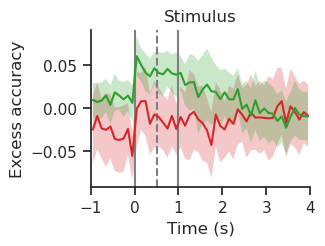

In [10]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='generalize', epoch='stim', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Stimulus')
# plt.title('Stimulus (decode stim.)\n'
#           f'ErrorL: {summary.ErrorLeft.iloc[0]}, '
#           f'ErrorR: {summary.ErrorRight.iloc[0]},\n'
#           f'CorrectL: {summary.CorrectLeft.iloc[0]}, '
#           f'CorrectR: {summary.CorrectRight.iloc[0]}, ')
plt.gca().get_legend().remove()

#### Delay code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 0.93 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.15 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.73 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 0.97 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 0.92 seconds to run
mean_decoder took 7.10 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.76 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.00 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.73 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.82 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 0.83 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.82 seconds to run
mean_decoder took 10.91 seconds to run


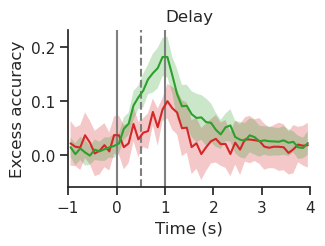

In [9]:
# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='stim', kind='generalize', epoch='delay', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Delay')
# plt.title('Stimulus (decode choice.)\n'
#           f'ErrorL: {summary.ErrorLeft.iloc[0]}, '
#           f'ErrorR: {summary.ErrorRight.iloc[0]},\n'
#           f'CorrectL: {summary.CorrectLeft.iloc[0]}, '
#           f'CorrectR: {summary.CorrectRight.iloc[0]}, ')
plt.gca().get_legend().remove()

#### Response code

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 0.93 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.73 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 0.91 seconds to run
mean_decoder took 7.30 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.76 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.00 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.73 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.82 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 0.83 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.84 seconds to run
mean_decoder took 11.02 seconds to run


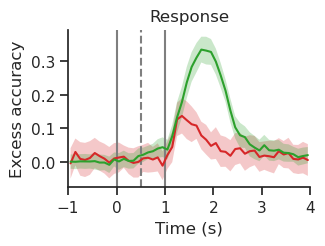

In [10]:
# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='stim', kind='generalize', epoch='resp', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.title('Response')
# plt.title('Stimulus (decode choice.)\n'
#           f'ErrorL: {summary.ErrorLeft.iloc[0]}, '
#           f'ErrorR: {summary.ErrorRight.iloc[0]},\n'
#           f'CorrectL: {summary.CorrectLeft.iloc[0]}, '
#           f'CorrectR: {summary.CorrectRight.iloc[0]}, ')
plt.gca().get_legend().remove()

#### First lick

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.08 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.33 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.86 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.13 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.07 seconds to run
mean_decoder took 13.78 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-4

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 905, in mean_decoder
    else:
AssertionError


epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.23 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.87 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.97 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.00 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.00 seconds to run
mean_decoder took 16.52 seconds to run


Text(0.5, 1.0, 'First lick')

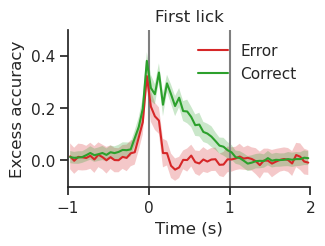

In [10]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='first_lick', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
plt.legend(loc='upper right')
plt.title('First lick')

#### Mid lick

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.43 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.89 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.19 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.11 seconds to run
mean_decoder took 14.47 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-4

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 905, in mean_decoder
    else:
AssertionError


epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.22 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.86 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.96 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
mean_decoder took 16.26 seconds to run


Text(0.5, 1.0, 'Mid lick')

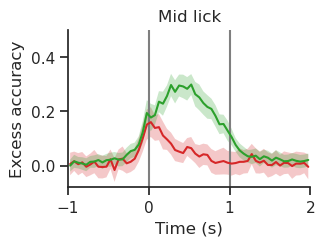

In [11]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='mid_lick', split_by='Hit', engagement=1, excess=True,  n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
plt.gca().get_legend().remove()
plt.title('Mid lick')

In [19]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='late_lick', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
plt.gca().get_legend().remove()
plt.title('Late lick')

NameError: name 'plot_mean_decoder_subjects_split' is not defined

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.17 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.41 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.90 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.20 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.13 seconds to run
mean_decoder took 9.40 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 886, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.94 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.24 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.87 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.01 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.06 seconds to run
mean_decoder took 13.32 seconds to run


Text(0.5, 1.0, 'Post lick')

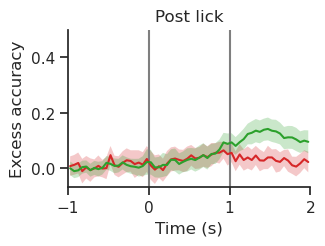

In [7]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='post_lick', split_by='Hit', engagement=1, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
plt.gca().get_legend().remove()
plt.title('Post response')

## By Engagement
Testing comparison of decoding accuracy of epoch cross decoder between engagement states (engaged vs disengaged)

### Train in all trials and test split by state
Epoch cross temporal decoder split

#### Stimulus

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 1.01 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 4.67 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.88 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 1.08 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.96 seconds to run
mean_decoder took 11.14 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.84 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 1.01 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.88 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 1.00 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 1.21 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.95 seconds to run
mean_decoder took 12.64 seconds to run


Text(0.5, 1.0, 'Stimulus')

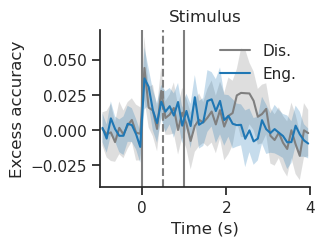

In [17]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='stim', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.title('Stimulus')

#### Delay

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 1.01 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 6.31 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.90 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 0.99 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.94 seconds to run
mean_decoder took 12.69 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.85 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 1.01 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.87 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 0.98 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 1.11 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.97 seconds to run
mean_decoder took 12.48 seconds to run


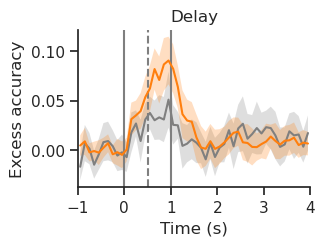

In [11]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='delay', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.title('Delay')
plt.gca().get_legend().remove()

#### Response

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_split took 1.02 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_split took 4.02 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_split took 0.89 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_split took 0.99 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_split took 0.96 seconds to run
mean_decoder took 10.33 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_split took 0.99 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_split took 1.17 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_split took 0.93 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_split took 0.97 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_split took 1.09 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_split took 0.94 seconds to run
mean_decoder took 12.54 seconds to run


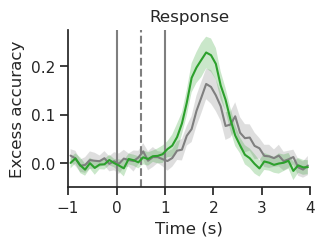

In [12]:
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='epoch_split', epoch='resp', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.title('Response')
plt.gca().get_legend().remove()

### Train in engaged and test in disengaged
Cross-validate in engaged, generalize in disengaged. Correct trials only\
Epoch cross temporal generalization decoder

#### Stimulus

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.47 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.85 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 1.00 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 0.98 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 0.96 seconds to run
mean_decoder took 8.92 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.76 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 0.93 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.90 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 1.01 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.89 seconds to run
mean_decoder took 11.33 seconds to run


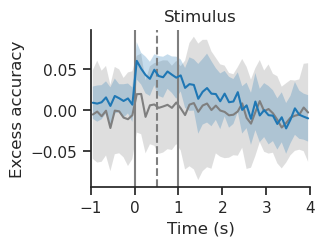

In [11]:
# Decode stimulus
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='stim', align='stim', kind='generalize', epoch='stim', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=False)
plt.title('Stimulus')
plt.gca().get_legend().remove()

#### Delay

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.48 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.57 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.07 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.09 seconds to run
mean_decoder took 8.68 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.75 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 0.90 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.88 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.09 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.88 seconds to run
mean_decoder took 11.08 seconds to run


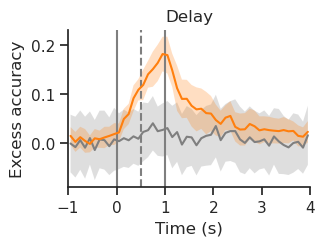

In [45]:
# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='stim', kind='generalize', epoch='delay', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=False)
plt.title('Delay')
plt.gca().get_legend().remove()

#### Response

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.64 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.48 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 0.93 seconds to run
mean_decoder took 8.39 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.75 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 0.91 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 0.89 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.09 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 0.88 seconds to run
mean_decoder took 10.99 seconds to run


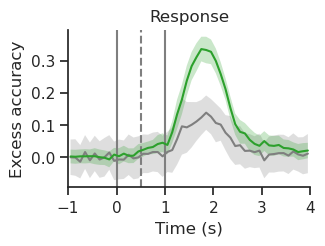

In [46]:
# Decode choice
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='stim', kind='generalize', epoch='resp', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=False)
plt.title('Response')
plt.gca().get_legend().remove()

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.77 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.65 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 1.11 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.10 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.10 seconds to run
mean_decoder took 9.63 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.90 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.25 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 1.15 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 1.20 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.33 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.05 seconds to run
mean_decoder took 13.74 seconds to run


Text(0.5, 1.0, 'First lick')

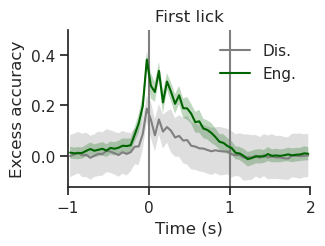

In [47]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='first_lick', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
# plt.gca().get_legend().remove()
plt.title('First lick')

This means that the licking code is not a stricktly motor signal: condition on the exact same motor action (1st lick) the neurons fire more in eng and less in diseng. The “conviction” or the “vigor” with what they make that lick is encoded in the firing of these neurons.

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.74 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.69 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.13 seconds to run
mean_decoder took 9.70 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.10 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 1.07 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 1.21 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.34 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.06 seconds to run
mean_decoder took 13.52 seconds to run


Text(0.5, 1.0, 'Mid lick')

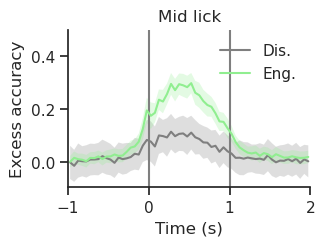

In [48]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='mid_lick', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
# plt.gca().get_legend().remove()
plt.title('Mid lick')

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.90 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 1.70 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.12 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.18 seconds to run
mean_decoder took 10.07 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-4

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.92 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.08 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 1.07 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 1.20 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.33 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.05 seconds to run
mean_decoder took 13.47 seconds to run


Text(0.5, 1.0, 'Late lick')

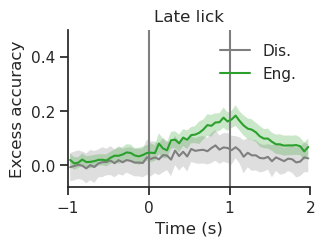

In [49]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='late_lick', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
# plt.gca().get_legend().remove()
plt.title('Late lick')

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept
epoch_cross_decoder_generalize took 1.75 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder_generalize took 2.00 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder_generalize took 1.23 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder_generalize took 1.15 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder_generalize took 1.15 seconds to run
mean_decoder took 10.39 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-4

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder_generalize took 0.99 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder_generalize took 1.18 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder_generalize took 1.17 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder_generalize took 1.31 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder_generalize took 1.42 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder_generalize took 1.14 seconds to run
mean_decoder took 14.27 seconds to run


Text(0.5, 1.0, 'Post response')

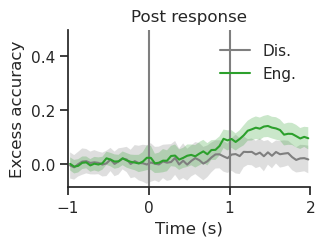

In [50]:
# Align to first lick
plot_mean_decoder_subjects_split(subjects, folder_parent, compute=True, what='choice', align='resp', kind='generalize', epoch='post_lick', split_by='State', hit_only=True, engagement=None, excess=True, n_shuffles=100, save=True)
plt.xlim(-1, None)
plt.ylim(None, 0.5)
# plt.gca().get_legend().remove()
plt.title('Post response')

### Train in disengaged and test in disengaged
Cross-validate in engaged, generalize in disengaged. Correct trials only\
Epoch cross temporal generalization decoder

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.46 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder took 0.55 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder took 0.44 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder took 0.46 seconds to run
mean_decoder took 5.16 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.46 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder took 0.53 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder took 0.44 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder took 0.45 seconds to run
mean_decoder took 4.23 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


...

epoch_cross_decoder took 0.43 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.38 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.40 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.62 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.57 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.60 seconds to run
mean_decoder took 8.16 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-0

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder took 0.39 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.45 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.41 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.44 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.40 seconds to run
mean_decoder took 7.77 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-0

Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder took 0.36 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.41 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.43 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.49 seconds to run
mean_decoder took 7.30 seconds to run


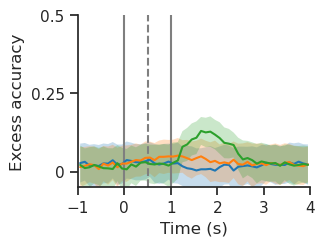

In [13]:
figsize = fig_size(n_cols=2)

# keys = ['acc', 'acc_null', 'pred', 'pred_err']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights', 'weights_null', 'dv', 'dv_null', 'df']

mean_results_stim = {k: [] for k in keys}
mean_results_delay = {k: [] for k in keys}
mean_results_resp = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_stim = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='stim', hit_only=True, engagement=0, n_shuffles=100, save=False)
        results_delay = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='delay', hit_only=True, engagement=0, n_shuffles=100, save=False)
        results_resp = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='resp', hit_only=True, engagement=0, n_shuffles=100, save=False)
    else:  # Load mean epoch cross decoder results across sessions
        filename_stim = 'stim_epoch_decoder_stim_hit_only_engaged_(stim_aligned).pkl'
        filename_delay = 'stim_epoch_decoder_delay_hit_only_engaged_(stim_aligned).pkl'
        filename_resp = 'stim_epoch_decoder_resp_hit_only_engaged_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_stim), 'rb') as f:
            results_stim = pickle.load(f)
        with open(Path(folder_parent / subj / filename_delay), 'rb') as f:
            results_delay = pickle.load(f)
        with open(Path(folder_parent / subj / filename_resp), 'rb') as f:
            results_resp = pickle.load(f)

    for k in keys:
        mean_results_stim[k].extend(results_stim.get(k, []))
        mean_results_stim['bins'] = results_stim['bins']
        mean_results_delay[k].extend(results_delay.get(k, []))
        mean_results_delay['bins'] = results_delay['bins']
        mean_results_resp[k].extend(results_resp.get(k, []))
        mean_results_resp['bins'] = results_resp['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
    # plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue
plot_mean_epoch_cross_decoder(mean_results_stim, epoch='stim', excess=True, errorbar='ci', z_null=True)
plot_mean_epoch_cross_decoder(mean_results_delay, epoch='delay', excess=True, errorbar='ci', z_null=True)
plot_mean_epoch_cross_decoder(mean_results_resp, epoch='resp', excess=True, errorbar='ci', z_null=True)
n_sessions = len(mean_results_stim['acc'])
n_trials = np.sum([mean_results_stim['acc'][i].shape[0] for i in range(len(mean_results_stim['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

#### Stimulus

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.46 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder took 0.70 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder took 0.56 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder took 0.49 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder took 0.47 seconds to run
mean_decoder took 6.52 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_

/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.40 seconds to run
Processing session 11/15: 007_2024-07-08_12-20-29...
859 / 859 units kept
epoch_cross_decoder took 0.51 seconds to run
Processing session 12/15: 007_2024-07-09_12-10-57...
556 / 556 units kept
epoch_cross_decoder took 0.52 seconds to run
Processing session 13/15: 007_2024-07-10_12-03-35...
251 / 251 units kept


...

An error occurred in session 007_2024-07-12_13-29-26: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1
mean_decoder took 15.68 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 939, in mean_decoder
    epoch_cross_decoder(bins, epoch, all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 468, in epoch_cross_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1


epoch_cross_decoder took 0.42 seconds to run
Processing session 2/9: 009_2024-05-09_20-59-38...
311 / 311 units kept
epoch_cross_decoder took 0.43 seconds to run
Processing session 3/9: 009_2024-05-10_17-38-35...
235 / 235 units kept
An error occurred in session 009_2024-05-10_17-38-35: 
Processing session 4/9: 009_2024-05-11_13-06-51...
189 / 189 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder took 0.48 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.39 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.56 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.50 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.49 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.46 seconds to run
mean_decoder took 8.49 seconds to run


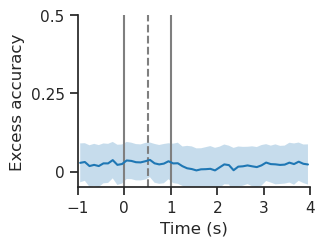

In [9]:
figsize = fig_size(n_cols=2)

# keys = ['acc', 'acc_null', 'pred', 'pred_err']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights', 'weights_null', 'dv', 'dv_null', 'df']

mean_results_stim = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_stim = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='stim', hit_only=True, engagement=0, n_shuffles=100, save=False)
    else:  # Load mean epoch cross decoder results across sessions
        filename_stim = 'stim_epoch_decoder_stim_hit_only_engaged_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_stim), 'rb') as f:
            results_stim = pickle.load(f)

    for k in keys:
        mean_results_stim[k].extend(results_stim.get(k, []))
        mean_results_stim['bins'] = results_stim['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue
plot_mean_epoch_cross_decoder(mean_results_stim, epoch='stim', excess=True, errorbar='ci', z_null=True)
n_sessions = len(mean_results_stim['acc'])
n_trials = np.sum([mean_results_stim['acc'][i].shape[0] for i in range(len(mean_results_stim['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

#### Delay

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.45 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder took 0.53 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder took 0.53 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder took 0.43 seconds to run
mean_decoder took 5.21 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_

/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.38 seconds to run
Processing session 11/15: 007_2024-07-08_12-20-29...
859 / 859 units kept
epoch_cross_decoder took 0.51 seconds to run
Processing session 12/15: 007_2024-07-09_12-10-57...
556 / 556 units kept
epoch_cross_decoder took 0.48 seconds to run
Processing session 13/15: 007_2024-07-10_12-03-35...
251 / 251 units kept


...

An error occurred in session 007_2024-07-12_13-29-26: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1
mean_decoder took 15.94 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 939, in mean_decoder
    epoch_cross_decoder(bins, epoch, all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 468, in epoch_cross_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1


epoch_cross_decoder took 0.42 seconds to run
Processing session 2/9: 009_2024-05-09_20-59-38...
311 / 311 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 3/9: 009_2024-05-10_17-38-35...
235 / 235 units kept
An error occurred in session 009_2024-05-10_17-38-35: 
Processing session 4/9: 009_2024-05-11_13-06-51...
189 / 189 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder took 0.40 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.43 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.44 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.45 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.56 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.44 seconds to run
mean_decoder took 9.07 seconds to run


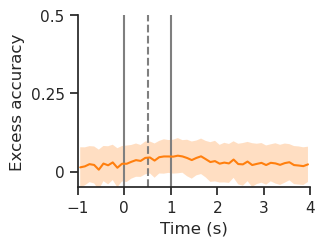

In [10]:
figsize = fig_size(n_cols=2)

# keys = ['acc', 'acc_null', 'pred', 'pred_err']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights', 'weights_null', 'dv', 'dv_null', 'df']

mean_results_delay = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_delay = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='delay', hit_only=True, engagement=0, n_shuffles=100, save=False)
    else:  # Load mean epoch cross decoder results across sessions
        filename_delay = 'stim_epoch_decoder_delay_hit_only_engaged_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_delay), 'rb') as f:
            results_delay = pickle.load(f)

    for k in keys:
        mean_results_delay[k].extend(results_delay.get(k, []))
        mean_results_delay['bins'] = results_delay['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue
plot_mean_epoch_cross_decoder(mean_results_delay, epoch='delay', excess=True, errorbar='ci', z_null=True)
n_sessions = len(mean_results_stim['acc'])
n_trials = np.sum([mean_results_stim['acc'][i].shape[0] for i in range(len(mean_results_stim['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

#### Response

Development mode: remote (minibaps, alexis, Linux)

['000_2024-07-08_14-58-57', '000_2024-07-09_14-45-54', '000_2024-07-10_14-32-41', '000_2024-07-11_14-50-25', '000_2024-07-12_15-42-10'] 

Processing session 1/5: 000_2024-07-08_14-58-57...
1181 / 1181 units kept


/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.47 seconds to run
Processing session 2/5: 000_2024-07-09_14-45-54...
1024 / 1024 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 3/5: 000_2024-07-10_14-32-41...
643 / 643 units kept
epoch_cross_decoder took 0.47 seconds to run
Processing session 4/5: 000_2024-07-11_14-50-25...
731 / 731 units kept
epoch_cross_decoder took 0.52 seconds to run
Processing session 5/5: 000_2024-07-12_15-42-10...
775 / 775 units kept
epoch_cross_decoder took 0.46 seconds to run
mean_decoder took 5.76 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['007_2024-06-22_10-48-57', '007_2024-06-23_12-46-55', '007_2024-06-24_17-47-22', '007_2024-06-25_15-54-23', '007_2024-06-26_15-19-30', '007_2024-06-27_15-06-28', '007_2024-06-28_14-18-51', '007_2024-06-29_16-24-52', '007_2024-07-06_11-16-25', '007_2024-07-07_13-20-29', '007_2024-07-08_12-20-29', '007_2024-07-09_12-10-57', '007_2024-07-10_12-03-35', '007_2024-07-11_12-39-21', '007_2024-07-12_

/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


epoch_cross_decoder took 0.37 seconds to run
Processing session 11/15: 007_2024-07-08_12-20-29...
859 / 859 units kept
epoch_cross_decoder took 0.49 seconds to run
Processing session 12/15: 007_2024-07-09_12-10-57...
556 / 556 units kept
epoch_cross_decoder took 0.48 seconds to run
Processing session 13/15: 007_2024-07-10_12-03-35...
251 / 251 units kept


...

An error occurred in session 007_2024-07-12_13-29-26: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1
mean_decoder took 14.63 seconds to run
Development mode: remote (minibaps, alexis, Linux)

['009_2024-05-08_20-51-26', '009_2024-05-09_20-59-38', '009_2024-05-10_17-38-35', '009_2024-05-11_13-06-51', '009_2024-05-12_15-23-28', '009_2024-05-13_18-00-11', '009_2024-05-22_17-46-48', '009_2024-05-23_17-40-35', '009_2024-05-24_19-45-45'] 

Processing session 1/9: 009_2024-05-08_20-51-26...
265 / 265 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 939, in mean_decoder
    epoch_cross_decoder(bins, epoch, all_psth, df_behavior[col], n_shuffles)
  File "/home/alexis/PycharmProjects/my_fun/my_fun.py", line 1044, in wrapper
    result = func(*args, **kwargs)
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 468, in epoch_cross_decoder
    clf.fit(X_train, y_train)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/alexis/anaconda3/envs/analysis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1


epoch_cross_decoder took 0.43 seconds to run
Processing session 2/9: 009_2024-05-09_20-59-38...
311 / 311 units kept
epoch_cross_decoder took 0.42 seconds to run
Processing session 3/9: 009_2024-05-10_17-38-35...
235 / 235 units kept
An error occurred in session 009_2024-05-10_17-38-35: 
Processing session 4/9: 009_2024-05-11_13-06-51...
189 / 189 units kept


Traceback (most recent call last):
  File "/home/alexis/PycharmProjects/ephys/decoder/decoder.py", line 900, in mean_decoder
    assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
AssertionError


epoch_cross_decoder took 0.40 seconds to run
Processing session 5/9: 009_2024-05-12_15-23-28...
485 / 485 units kept
epoch_cross_decoder took 0.37 seconds to run
Processing session 6/9: 009_2024-05-13_18-00-11...
103 / 103 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 7/9: 009_2024-05-22_17-46-48...
235 / 235 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 8/9: 009_2024-05-23_17-40-35...
346 / 346 units kept
epoch_cross_decoder took 0.46 seconds to run
Processing session 9/9: 009_2024-05-24_19-45-45...
183 / 183 units kept
epoch_cross_decoder took 0.42 seconds to run
mean_decoder took 7.80 seconds to run


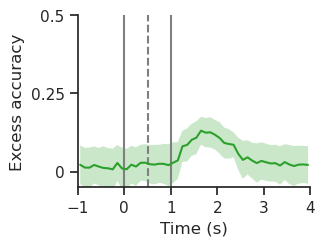

In [12]:
figsize = fig_size(n_cols=2)

# keys = ['acc', 'acc_null', 'pred', 'pred_err']
keys = ['acc', 'acc_null', 'pred', 'pred_err', 'weights', 'weights_null', 'dv', 'dv_null', 'df']

mean_results_resp = {k: [] for k in keys}

for subj in subjects:

    if compute:  # Run mean epoch cross decoder across sessions
        results_resp = mean_decoder(subject=subj, what='stim', kind='epoch', epoch='resp', hit_only=True, engagement=0, n_shuffles=100, save=False)
    else:  # Load mean epoch cross decoder results across sessions
        filename_resp = 'stim_epoch_decoder_resp_hit_only_engaged_(stim_aligned).pkl'
        with open(Path(folder_parent / subj / filename_resp), 'rb') as f:
            results_resp = pickle.load(f)

    for k in keys:
        mean_results_resp[k].extend(results_resp.get(k, []))
        mean_results_resp['bins'] = results_resp['bins']

    # # Plot mean epoch cross decoder results across sessions
    # plt.figure(constrained_layout=True, figsize=figsize)
    # plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
    # n_sessions = len(results_stim['acc'])
    # n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
    # plt.title(f'Decoding accuracy\n'
    #           f'{subj}, {n_sessions} sessions, {n_trials} trials')

# Plot mean within decoder results across mice
plt.figure(constrained_layout=True, figsize=figsize)
plt.axvline(0, color='tab:gray', linestyle='-')  # Stimulus onset
plt.axvline(0.5, color='tab:gray', linestyle='--')  # Delay
plt.axvline(1, color='tab:gray', linestyle='-')  # Go cue
plot_mean_epoch_cross_decoder(mean_results_resp, epoch='resp', excess=True, errorbar='ci', z_null=True)
n_sessions = len(mean_results_stim['acc'])
n_trials = np.sum([mean_results_stim['acc'][i].shape[0] for i in range(len(mean_results_stim['acc']))])
# plt.title(f'Decoding accuracy\n'
#           f'{len(subjects)} mice, {n_sessions} sessions, {n_trials} trials')
plt.gca().get_legend().remove()

# Population selectivity analysis

From:
Inagaki, H. K., Chen, S., Ridder, M. C., Sah, P., Li, N., Yang, Z., Hasanbegovic, H., Gao, Z., Gerfen, C. R., & Svoboda, K. (2022). A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement. Cell, 185(6), 1065-1081.e23. https://doi.org/10.1016/j.cell.2022.02.006

In [17]:
# Align to stimulus onset
df_behavior = behavior[0]
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')

# Step 1: Separate trials by condition
left_lick_trials = df_behavior[df_behavior.Choice == 0].Trial
right_lick_trials = df_behavior[df_behavior.Choice == 1].Trial

# Step 2: Compute mean firing rates per time bin
r_lick_left = np.mean(all_psth[left_lick_trials], axis=0)  # shape (bins, neurons)
r_lick_right = np.mean(all_psth[right_lick_trials], axis=0)  # shape (bins, neurons)

# Step 3: Compute selectivity vector w_t
wt = r_lick_right - r_lick_left  # shape (bins, neurons)

# Step 4: Perform SVD to get the dominant coding direction
U, S, Vt = np.linalg.svd(wt, full_matrices=False)

# Step 5: CD_delay is the first right singular vector (principal axis)
CD_delay = Vt[0, :]  # First singular vector (neurons,)

# Step 6: Normalize to unit vector
CD_delay /= np.linalg.norm(CD_delay)

# Step 7: Compute correlation matrix
corr_matrix = np.corrcoef(wt)
# np.fill_diagonal(corr_matrix, np.nan)  # Remove diagonal by setting it to NaN

# Step 8: Plot correlation matrix
plt.figure(constrained_layout=True)
plt.imshow(corr_matrix, cmap='coolwarm', origin='lower')
plt.axhline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axvline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axhline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axvline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axhline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.axvline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.xticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.yticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.colorbar(label="Pearson's correlation\nof selectivity vector")
plt.xlabel('Time from stim. onset (s)')
plt.ylabel('Time from stim. onset (s)')
# plt.title('Correlation of Population Selectivity Over Time')
sns.despine()

NameError: name 'behavior' is not defined

Pearson's correlation is high during the delay epoch (0.5-1 s), meaning that a similar subpopulation of neurons holds selectivity during motor planning. In contrast, population selectivity show a low correlation before and after the Go cue (1 s), meaning that different subpopulations of neurons show selectivity. Population activity patterns in M2 change rapidly before and during movement initiation.

# Test

In [7]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
import threadpoolctl
threadpoolctl.threadpool_info()

from licks import *
from ephys.decoder import *
from my_fun.my_fun import fig_size, save_notebook_files

# Magics
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'png'

# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'

subjects = ['000', '007', '009']  # Removed 001 (all sessions bad)
folder_parent = Path.home() / 'data'
compute = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
# Example session
subject = '007'
ephys_id = '007_2024-06-24_17-47-22'
# ephys_id = '007_2024-06-23_12-46-55'
preprocessed = preprocess(ephys_id)
cluster_info = preprocessed.cluster_info
df_behavior = preprocessed.df_behavior

align = 'stim'
folder_parent = Path.home() / 'data' / subject
folder_child = folder_parent / ephys_id
bins = np.load(folder_child / f'bins_{align}.npy')
all_psth = np.load(folder_child / f'all_psth_{align}.npy')

# Load GLM-HMM fit
path_glmhmm = ((Path.home() / 'PycharmProjects' / 'glmhmm' / 'TEST' / '2s_3cov' / 'Ephys' / subject)
               .with_suffix('.csv'))  # Fitted sphys sessions only
df_glmhmm = pd.read_csv(path_glmhmm)  # All sessions concatenated
session = df_behavior.Session.unique()[0]
df_glmhmm = df_glmhmm[df_glmhmm.Session == session].reset_index(drop=True)

# Drop misses (GLM-HMM lack misses)
resp_idx = df_behavior[df_behavior.Miss == 0].index
df_behavior = df_behavior.iloc[resp_idx].reset_index(drop=True)
all_psth = all_psth[resp_idx]
assert len(df_glmhmm) == len(df_behavior)  # Check sessions match
df_behavior = df_glmhmm
print(f'Len original df: {len(df_behavior)}')

idx = df_behavior.index[(df_behavior['Hit'] == 1) & (df_behavior['State'] == 1)].to_numpy()
df_behavior = df_behavior.loc[idx].reset_index(drop=True)
all_psth = all_psth[idx, :, :]

Development mode: remote (minibaps, alexis, Linux)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 59449398
  Last event sample number: 230358711
  Total sync events: 6000
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 4954116
  Last event sample number: 19196559
  Total sync events: 4763
  Scale factor: 11.99999978936198
  Actual sample rate: 2500.0000438829215


Development mode: remote (minibaps, alexis, Linux)

All sounds sent by Bpod match those received by Arduino
There is(are) 1 more ephys trial(s) than behavior trial(s)
999 trials common to both data sources. Using it for later slicing
All sounds from behavior and ephys match


Min spike time: 0 min
Max spike time: 126 min


The aquisition (press PLAY in Open Ephys) started at 0 min and ended after 144 min. It includes the time for lowering the probe.
The recording (press REC in Open Ephys) started at 18 

# Link late delay DV with Licks

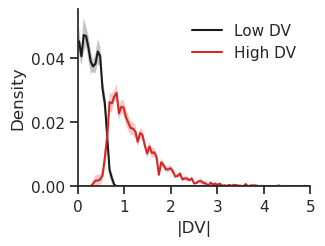

In [25]:
bins = mean_results_delay['bins']
bin_delay = np.where(np.isclose(bins, 0.9))[0][0]
hist_bins = np.linspace(0, 5, 100)

mask = [[], []]
all_hist_low = []
all_hist_high = []

for dv_session in mean_results_delay['dv']:

    n_trials = dv_session.shape[0]
    dv_session = dv_session[:, bin_delay]
    dv_session = np.abs(dv_session)
    median_dv = np.median(dv_session)  # 50th percentile

    # Median split
    low_mask = dv_session <= median_dv
    high_mask = dv_session > median_dv
    mask[0].append(low_mask)
    mask[1].append(high_mask)

    dv_session_low = dv_session[low_mask]
    dv_sesion_high = dv_session[high_mask]

    weights_low = np.ones(np.sum(low_mask)) / n_trials
    weights_high = np.ones(np.sum(high_mask)) / n_trials
    hist_low, _ = np.histogram(dv_session_low, bins=hist_bins, weights=weights_low)
    hist_high, _ = np.histogram(dv_sesion_high, bins=hist_bins, weights=weights_high)
    all_hist_low.append(hist_low)
    all_hist_high.append(hist_high)

# Mean ± across sessions
mean_hist_low = np.mean(all_hist_low, axis=0)
mean_hist_high = np.mean(all_hist_high, axis=0)
sem_hist_low = sem(all_hist_low, axis=0)
sem_hist_high = sem(all_hist_high, axis=0)

plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
bin_centers = (hist_bins[:-1] + hist_bins[1:]) / 2
plt.plot(bin_centers, mean_hist_low, color='k', label='Low DV')
plt.plot(bin_centers, mean_hist_high, color='tab:red', label='High DV')
plt.fill_between(bin_centers, mean_hist_low - sem_hist_low, mean_hist_low + sem_hist_low, color='k', edgecolor='none', alpha=0.25)
plt.fill_between(bin_centers, mean_hist_high - sem_hist_high, mean_hist_high + sem_hist_high, color='tab:red', edgecolor='none', alpha=0.25)
plt.xlim(0, 5)
plt.ylim(0, None)
plt.xlabel('|DV|')
plt.ylabel('Density')
plt.legend()
sns.despine()

In [26]:
df_low_all = []
df_high_all = []

for i, df in enumerate(mean_results_delay['df']):
    df = add_lick_data(df)
    df.RT -= 0.15
    low_mask = mask[0][i]
    high_mask = mask[1][i]
    df_low_all.append(df.loc[low_mask])
    df_high_all.append(df.loc[high_mask])

df_low_all = pd.concat(df_low_all, ignore_index=True)
df_high_all = pd.concat(df_high_all, ignore_index=True)

0.47% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.35% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.23% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.00% of premature lick trials (before response window)
Port1In or Port2In are already lists
1.50% of premature lick trials (before response window)
Port1In or Port2In are already lists
3.10% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.37% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.84% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.00% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.67% of premature lick trials (before response window)
Port1In or Port2In are already lists
0.47% of premature lick trials (before response window)
Port1In or Por

/tmp/ipykernel_1811322/3448586574.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


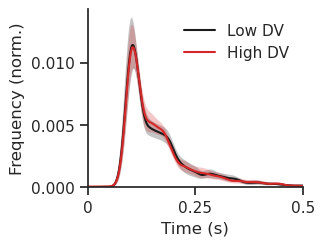

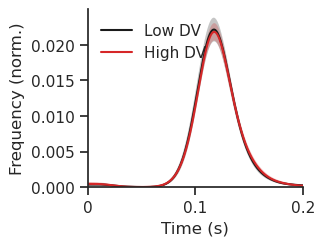

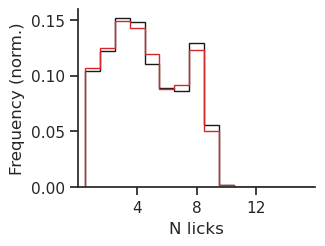

In [30]:
plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
plot_licks_dist(df_low_all, var='RT', color='k', sem=True, label='Low DV',)
plot_licks_dist(df_high_all, var='RT', color='tab:red', sem=True, label='High DV')
plt.legend(loc='upper right')

plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
plot_licks_dist(df_low_all, var='ILI', color='k', sem=True, label='Low DV')
plot_licks_dist(df_high_all, var='ILI', color='tab:red', sem=True, label='High DV')
plt.legend(loc='upper left')

plt.figure(figsize=fig_size(n_cols=2), constrained_layout=True)
plot_licks_dist(df_low_all, var='nLicks', color='k', sem=True, label='Low DV')
plot_licks_dist(df_high_all, var='nLicks', color='tab:red', sem=True, label='High DV')
plt.legend(loc='upper right')

Port1In or Port2In are already lists
0.47% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.35% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.23% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.00% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
1.50% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
3.10% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.37% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.84% of premature lick trials (before response windo

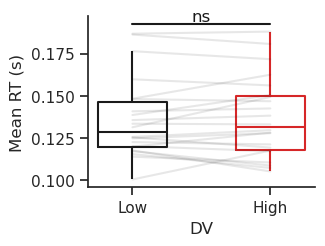

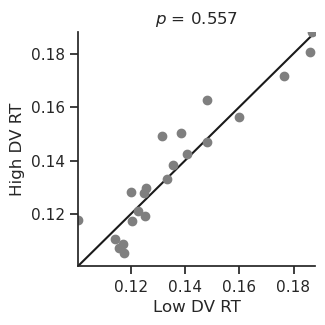

In [57]:
var = 'RT'

# Compute mean RT per session
mean_var_low = []
mean_var_high = []

for i, df in enumerate(mean_results_delay['df']):
    df = add_lick_data(df)
    df.RT -= 0.15
    low_mask = mask[0][i]
    high_mask = mask[1][i]
    mean_var_low.append(df.loc[low_mask, var].mean())
    mean_var_high.append(df.loc[high_mask, var].mean())

# Paired t-test
t_stat, p_val = ttest_rel(mean_var_low, mean_var_high)

# Prepare data for seaborn
import pandas as pd
df_plot = pd.DataFrame({
    var: mean_var_low + mean_var_high,
    'DV': ['Low']*len(mean_var_low) + ['High']*len(mean_var_high),
    'Session': list(range(len(mean_var_low)))*2
})

figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(x='DV', y=var, data=df_plot, palette=['k','tab:red'], width=0.5, showfliers=False, showcaps=False,
                     fill=False, legend=False)
sns.lineplot(data=df_plot, x='DV', y=var, units='Session', estimator=None, alpha=0.1, color='k', legend=False)
add_star_between(p_val)
plt.ylabel(f'Mean {var} (s)')
# plt.title(f'Paired t-test: p = {p_val:.3f}')
sns.despine()

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])
plt.figure(figsize=figsize, constrained_layout=True)
plt.scatter(mean_var_low, mean_var_high, color='tab:gray')
lims = [min(min(mean_var_low), min(mean_var_high)), max(max(mean_var_low), max(mean_var_high))]
plt.plot(lims, lims, '-', color='k', zorder=0)

# Squared axes
ticks = (0.1, 0.12, 0.14, 0.16, 0.18, 0.2)
plt.xlim(lims)
plt.ylim(lims)
# plt.xticks(ticks)
# plt.yticks(ticks)
# plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(f'Low DV {var}')
plt.ylabel(f'High DV {var}')
plt.title(f'$p$ = {p_val:.3f}')
sns.despine()

Port1In or Port2In are already lists
0.47% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.35% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.23% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.00% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
1.50% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
3.10% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.37% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.84% of premature lick trials (before response windo

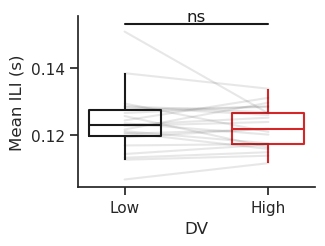

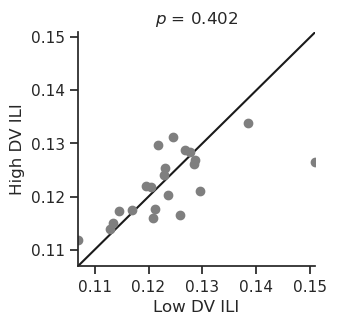

In [58]:
var = 'ILI'

# Compute mean RT per session
mean_var_low = []
mean_var_high = []

for i, df in enumerate(mean_results_delay['df']):
    df = add_lick_data(df)
    df.RT -= 0.15
    low_mask = mask[0][i]
    high_mask = mask[1][i]
    mean_var_low.append(df.loc[low_mask, var].mean())
    mean_var_high.append(df.loc[high_mask, var].mean())

# Paired t-test
t_stat, p_val = ttest_rel(mean_var_low, mean_var_high)

# Prepare data for seaborn
import pandas as pd
df_plot = pd.DataFrame({
    var: mean_var_low + mean_var_high,
    'DV': ['Low']*len(mean_var_low) + ['High']*len(mean_var_high),
    'Session': list(range(len(mean_var_low)))*2
})

figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(x='DV', y=var, data=df_plot, palette=['k','tab:red'], width=0.5, showfliers=False, showcaps=False,
                     fill=False, legend=False)
sns.lineplot(data=df_plot, x='DV', y=var, units='Session', estimator=None, alpha=0.1, color='k', legend=False)
add_star_between(p_val)
plt.ylabel(f'Mean {var} (s)')
# plt.title(f'Paired t-test: p = {p_val:.3f}')
sns.despine()

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])
plt.figure(figsize=figsize, constrained_layout=True)
plt.scatter(mean_var_low, mean_var_high, color='tab:gray')
lims = [min(min(mean_var_low), min(mean_var_high)), max(max(mean_var_low), max(mean_var_high))]
plt.plot(lims, lims, '-', color='k', zorder=0)

# Squared axes
ticks = (0.1, 0.12, 0.14, 0.16, 0.18, 0.2)
plt.xlim(lims)
plt.ylim(lims)
# plt.xticks(ticks)
# plt.yticks(ticks)
# plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(f'Low DV {var}')
plt.ylabel(f'High DV {var}')
plt.title(f'$p$ = {p_val:.3f}')
sns.despine()

Port1In or Port2In are already lists
0.47% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.35% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.23% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.00% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
1.50% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
3.10% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.37% of premature lick trials (before response window)
Port1In or Port2In are already lists
Port1In or Port2In are already lists
0.84% of premature lick trials (before response windo

/tmp/ipykernel_1533282/4238765609.py:45: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(lims)
/tmp/ipykernel_1533282/4238765609.py:46: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lims)


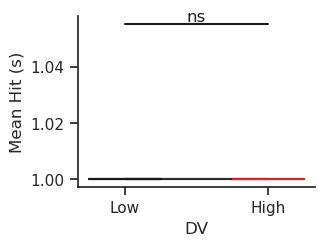

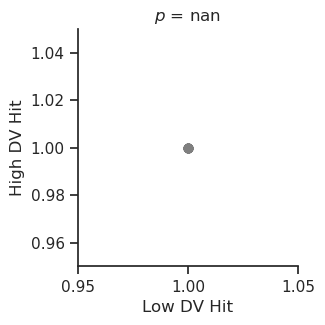

In [68]:
var = 'Hit'

# Compute mean RT per session
mean_var_low = []
mean_var_high = []

for i, df in enumerate(mean_results_delay['df']):
    df = add_lick_data(df)
    df.RT -= 0.15
    low_mask = mask[0][i]
    high_mask = mask[1][i]
    mean_var_low.append(df.loc[low_mask, var].mean())
    mean_var_high.append(df.loc[high_mask, var].mean())

# Paired t-test
t_stat, p_val = ttest_rel(mean_var_low, mean_var_high)

# Prepare data for seaborn
import pandas as pd
df_plot = pd.DataFrame({
    var: mean_var_low + mean_var_high,
    'DV': ['Low']*len(mean_var_low) + ['High']*len(mean_var_high),
    'Session': list(range(len(mean_var_low)))*2
})

figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(x='DV', y=var, data=df_plot, palette=['k','tab:red'], width=0.5, showfliers=False, showcaps=False,
                     fill=False, legend=False)
sns.lineplot(data=df_plot, x='DV', y=var, units='Session', estimator=None, alpha=0.1, color='k', legend=False)
add_star_between(p_val)
plt.ylabel(f'Mean {var} (s)')
# plt.title(f'Paired t-test: p = {p_val:.3f}')
sns.despine()

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])
plt.figure(figsize=figsize, constrained_layout=True)
plt.scatter(mean_var_low, mean_var_high, color='tab:gray')
lims = [min(min(mean_var_low), min(mean_var_high)), max(max(mean_var_low), max(mean_var_high))]
plt.plot(lims, lims, '-', color='k', zorder=0)

# Squared axes
# ticks = (0.1, 0.12, 0.14, 0.16, 0.18, 0.2)
plt.xlim(lims)
plt.ylim(lims)
# plt.xticks(ticks)
# plt.yticks(ticks)
# plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(f'Low DV {var}')
plt.ylabel(f'High DV {var}')
plt.title(f'$p$ = {p_val:.3f}')
sns.despine()

# Ipsi/contra

In [11]:
def plot_weights_depth(cluster_info, epoch, bin_size=0.1, ipsi_contra=False, plot_type='scatter', ax=None):

    # Extract full dataset (no early filtering)
    weights = cluster_info['weights'].to_numpy()
    rec_side = cluster_info['RECside'].to_numpy()
    depth = cluster_info['depth'].to_numpy() / 1000  # mm
    selective_mask = cluster_info['selective_mask'].to_numpy()

    # Flip weights if needed
    if ipsi_contra:
        weights = lr2ic(weights, rec_side)
        labels = ('Contra', 'Ipsi')
    else:
        labels = ('Left', 'Right')

    # Epoch styling
    if epoch == 'stim':
        color = 'tab:blue'
        title = 'Stimulus'
    elif epoch == 'delay':
        color = 'tab:orange'
        title = 'Delay'
    elif epoch == 'resp':
        color = 'tab:green'
        title = 'Response'
    else:
        raise ValueError("epoch must be 'stim', 'delay', or 'resp'")

    if plot_type == 'scatter':

        # Scatter only selective neurons
        mask = selective_mask
        ax.scatter(weights[mask], depth[mask], facecolors='none', edgecolors=color)
        xlim = (-1, 1)
        xticks = (-1, 0, 1)
        xticklabels = ('-1', '0', '1')
        text_xy = (0.5, 4)
        xlabel = 'Weight'

    elif plot_type == 'hist':

        # Depth bins from full dataset
        dmin = np.floor(depth.min() / bin_size) * bin_size
        dmax = np.ceil(depth.max() / bin_size) * bin_size
        bins = np.arange(dmin, dmax + bin_size, bin_size)
        bin_centers = bins[:-1] + bin_size / 2

        pos_counts = []
        neg_counts = []
        for i in range(len(bins) - 1):
            mask_bin = (depth >= bins[i]) & (depth < bins[i+1])
            n_total = np.sum(mask_bin)
            if n_total == 0:
                pos_counts.append(0)
                neg_counts.append(0)
                continue
            n_pos = np.sum(mask_bin & selective_mask & (weights > 0))
            n_neg = np.sum(mask_bin & selective_mask & (weights < 0))
            pos_counts.append(n_pos / n_total)
            neg_counts.append(n_neg / n_total)
        pos_counts = np.array(pos_counts)
        neg_counts = np.array(neg_counts)

        ax.barh(bin_centers, -neg_counts, height=bin_size, color=color, edgecolor='k', alpha=0.5)
        ax.barh(bin_centers, pos_counts, height=bin_size, color=color, edgecolor='k', alpha=0.5)
        xlim = (-0.5, 0.5)
        xticks = (-0.5, 0, 0.5)
        xticklabels = ('-0.5', '0', '0.5')
        text_xy = (0.25, 4)
        xlabel = 'Fraction of neurons'

    ax.axvline(0, linestyle='--', color='tab:gray')
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_ylim(4, 0)
    ax.set_yticks(np.arange(5))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)
    ax.text(-text_xy[0], text_xy[1], labels[0], ha='center', va='bottom')
    ax.text(text_xy[0], text_xy[1], labels[1], ha='center', va='bottom')
    sns.despine(ax=ax)

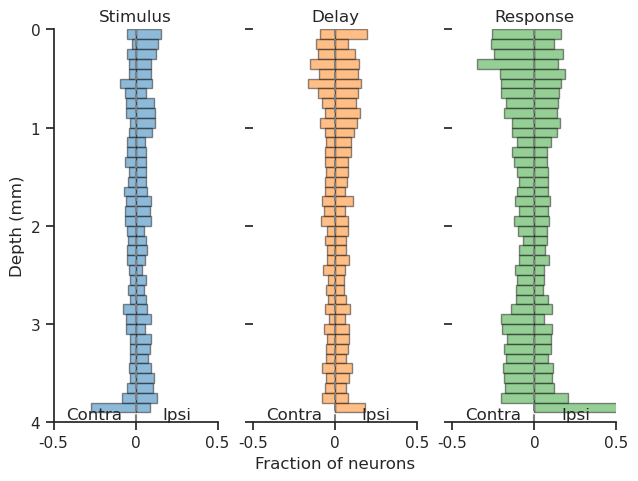

In [12]:
figsize = fig_size(n_cols=1)
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)
plot_weights_depth(cluster_info_stim, 'stim', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[0])
plot_weights_depth(cluster_info_delay, 'delay', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[1])
plot_weights_depth(cluster_info_resp, 'resp', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[2])
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[0].set_xlabel('')
axes[2].set_xlabel('')
axes[1].spines['left'].set_visible(False)
axes[2].spines['left'].set_visible(False)

In [13]:
def plot_weights_depth(cluster_info, epoch, bin_size=0.1, ipsi_contra=False, plot_type='scatter', ax=None):

    # Extract full dataset (no early filtering)
    weights = cluster_info['weights'].to_numpy()
    rec_side = cluster_info['RECside'].to_numpy()
    depth = cluster_info['depth'].to_numpy() / 1000  # mm
    selective_mask = cluster_info['selective_mask'].to_numpy()

    # Flip weights if needed
    if ipsi_contra:
        weights = lr2ic(weights, rec_side)
        labels = ('Contra', 'Ipsi')
    else:
        labels = ('Left', 'Right')

    # Epoch styling
    if epoch == 'stim':
        color = 'tab:blue'
        title = 'Stimulus'
    elif epoch == 'delay':
        color = 'tab:orange'
        title = 'Delay'
    elif epoch == 'resp':
        color = 'tab:green'
        title = 'Response'
    else:
        raise ValueError("epoch must be 'stim', 'delay', or 'resp'")

    if plot_type == 'scatter':

        # Scatter only selective neurons
        mask = selective_mask
        ax.scatter(weights[mask], depth[mask], facecolors='none', edgecolors=color)
        xlim = (-1, 1)
        xticks = (-1, 0, 1)
        xticklabels = ('-1', '0', '1')
        xlabel = 'Weight'

    elif plot_type == 'hist':
        # Depth bins
        dmin = np.floor(depth.min() / bin_size) * bin_size
        dmax = np.ceil(depth.max() / bin_size) * bin_size
        bins = np.arange(dmin, dmax + bin_size, bin_size)
        bin_centers = bins[:-1] + bin_size / 2

        # Count selective neurons per depth bin
        counts = []
        for i in range(len(bins) - 1):
            mask_bin = (depth >= bins[i]) & (depth < bins[i+1])
            n_total = np.sum(mask_bin)
            if n_total == 0:
                counts.append(0)
                continue
            n_sel = np.sum(mask_bin & selective_mask)  # Only count selective neurons, ignore weight sign
            counts.append(n_sel / n_total)  # Fraction of neurons selective in this bin
        counts = np.array(counts)

        ax.barh(bin_centers, counts, height=bin_size, color=color, edgecolor='k', alpha=0.5)
        xlim = (0, 0.5)
        xticks = (0, 0.25, 0.5)
        xticklabels = ('0', '0.25', '0.5')
        xlabel = 'Fraction of selective neurons'

    ax.axvline(0, linestyle='--', color='tab:gray')
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_ylim(4, 0)
    ax.set_yticks(np.arange(5))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)
    sns.despine(ax=ax)

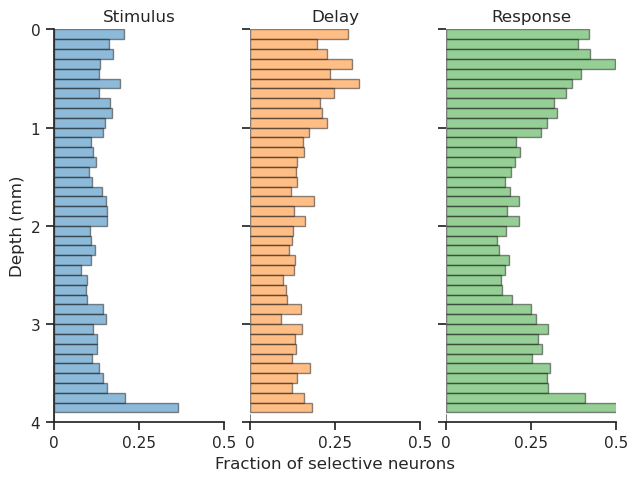

In [14]:
figsize = fig_size(n_cols=1)
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharex=True, sharey=True)
plot_weights_depth(cluster_info_stim, 'stim', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[0])
plot_weights_depth(cluster_info_delay, 'delay', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[1])
plot_weights_depth(cluster_info_resp, 'resp', bin_size=0.1, ipsi_contra=True, plot_type='hist', ax=axes[2])
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[0].set_xlabel('')
axes[2].set_xlabel('')
axes[1].spines['left'].set_visible(False)
axes[2].spines['left'].set_visible(False)

# Save all notebook's figures

In [41]:
# Whole notebook ouputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF
os.chdir(Path.home() / 'PycharmProjects' / 'ephys' / 'decoder')
save_notebook_files('notebook.ipynb')  # Export all figures

Saved 58 images to notebook_files/
